# Import thư viện

In [1]:
! pip install sns

In [39]:
import numpy as np
import pandas as pd
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Data

In [3]:
train = pd.read_csv("flight_data_24_25/train.csv")
print(f"Tập Train loaded thành công: {train.shape[0]} dòng, {train.shape[1]} cột.")

val = pd.read_csv("flight_data_24_25/valid.csv")
print(f"Tập Validation loaded thành công: {val.shape[0]} dòng, {val.shape[1]} cột.")

test = pd.read_csv("flight_data_24_25/test.csv")
print(f"Tập Test loaded thành công: {test.shape[0]} dòng, {test.shape[1]} cột.")

gc.collect()


Tập Train loaded thành công: 9691316 dòng, 43 cột.
Tập Validation loaded thành công: 2076712 dòng, 43 cột.
Tập Test loaded thành công: 2076711 dòng, 43 cột.


24

# DATA UNDERSTANDING

In [4]:
print(train.info())
display(train.describe())


<class 'pandas.DataFrame'>
RangeIndex: 9691316 entries, 0 to 9691315
Data columns (total 43 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   year                    int64  
 1   month                   int64  
 2   day_of_month            int64  
 3   day_of_week             int64  
 4   crs_arr_time            int64  
 5   arr_delay               float64
 6   crs_elapsed_time        float64
 7   distance                float64
 8   hour                    int64  
 9   minute                  int64  
 10  temperature_2m          float64
 11  surface_pressure        float64
 12  relative_humidity_2m    int64  
 13  dew_point_2m            float64
 14  wind_speed_10m          float64
 15  wind_direction_10m      int64  
 16  cloud_cover             int64  
 17  origin_te               float64
 18  dest_te                 float64
 19  op_unique_carrier_AA    int64  
 20  op_unique_carrier_AS    int64  
 21  op_unique_carrier_B6    int64  
 22  op_un

,year,month,day_of_month,day_of_week,crs_arr_time,arr_delay,crs_elapsed_time,distance,hour,minute,...,weather_Rain,weather_Snow_Ice,season,time_of_day,weather_severity_score,is_bad_weather,wind_risk,rush_hour_x_weather,weather_impact_squared,wind_per_mile
count,9.691316e+06,9.691316e+06,9.691316e+06,9.691316e+06,9.691316e+06,9.691316e+06,9.691316e+06,9.691316e+06,9.691316e+06,9.691316e+06,...,9.691316e+06,9.691316e+06,9.691316e+06,9.691316e+06,9.691316e+06,9.691316e+06,9.691316e+06,9.691316e+06,9.691316e+06,9.691316e+06
mean,2.024281e+03,5.597156e+00,1.567978e+01,3.985372e+00,1.491916e+03,6.563923e+00,1.476538e+02,8.375154e+02,1.298303e+01,2.691892e+01,...,1.181867e-01,1.212291e-02,1.277848e+00,9.378262e-01,6.516547e-01,1.303097e-01,8.467281e-02,2.865796e-01,4.319974e-01,2.327033e-02
std,4.496278e-01,3.376445e+00,8.736668e+00,2.009534e+00,5.183693e+02,5.215982e+01,7.279884e+01,5.974031e+02,4.891044e+00,1.823347e+01,...,3.228291e-01,1.094347e-01,1.053224e+00,9.503805e-01,7.556128e-01,3.366438e-01,9.805350e-02,5.914977e-01,1.259005e+00,2.928429e-02
min,2.024000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-5.100000e+01,2.000000e+01,3.100000e+01,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.024000e+03,3.000000e+00,8.000000e+00,2.000000e+00,1.104000e+03,-1.600000e+01,9.400000e+01,4.000000e+02,9.000000e+00,1.000000e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.510638e-04,0.000000e+00,0.000000e+00,7.522388e-03
50%,2.024000e+03,5.000000e+00,1.600000e+01,4.000000e+00,1.517000e+03,-6.000000e+00,1.310000e+02,6.890000e+02,1.300000e+01,2.700000e+01,...,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,4.923404e-02,0.000000e+00,0.000000e+00,1.433022e-02
75%,2.025000e+03,8.000000e+00,2.300000e+01,6.000000e+00,1.925000e+03,9.000000e+00,1.790000e+02,1.072000e+03,1.700000e+01,4.300000e+01,...,0.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,1.393475e-01,0.000000e+00,0.000000e+00,2.723493e-02
max,2.025000e+03,1.200000e+01,3.100000e+01,7.000000e+00,2.359000e+03,7.390000e+02,8.590000e+02,5.095000e+03,2.300000e+01,5.900000e+01,...,1.000000e+00,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00,1.600000e+01,1.006250e+00


# UNIVARIATE ANALYSIS

**Arr_delay**

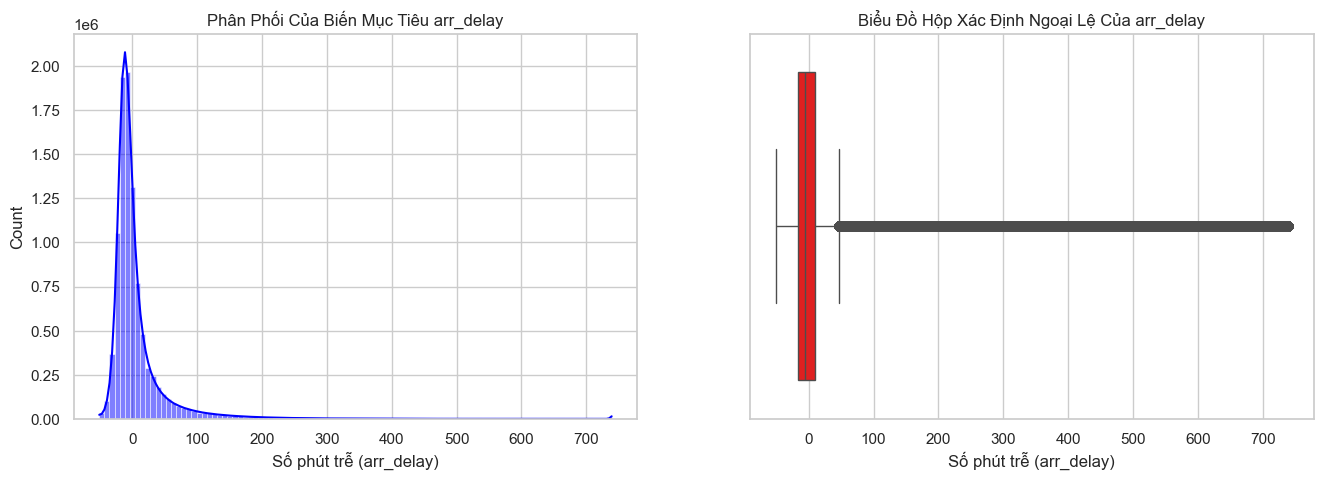

--- Thống kê mô tả của arr_delay ---
count    9.691316e+06
mean     6.563923e+00
std      5.215982e+01
min     -5.100000e+01
25%     -1.600000e+01
50%     -6.000000e+00
75%      9.000000e+00
max      7.390000e+02
Name: arr_delay, dtype: float64
Độ lệch (Skewness): 6.4019
Độ nhọn (Kurtosis): 64.9097


In [5]:
# Thiết lập cấu hình vẽ đồ thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# 1. Vẽ phân phối tổng thể và hộp (Boxplot) để trực quan hóa độ lệch và outlier
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(train['arr_delay'], bins=100, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Phân Phối Của Biến Mục Tiêu arr_delay')
axes[0].set_xlabel('Số phút trễ (arr_delay)')

sns.boxplot(x=train['arr_delay'], ax=axes[1], color='red')
axes[1].set_title('Biểu Đồ Hộp Xác Định Ngoại Lệ Của arr_delay')
axes[1].set_xlabel('Số phút trễ (arr_delay)')
plt.show()

# 2. Tính toán các chỉ số thống kê mô tả chi tiết
print("--- Thống kê mô tả của arr_delay ---")
print(train['arr_delay'].describe())
print(f"Độ lệch (Skewness): {train['arr_delay'].skew():.4f}")
print(f"Độ nhọn (Kurtosis): {train['arr_delay'].kurt():.4f}")

Phản ánh một thực tế rất đặc trưng của ngành hàng không: phần lớn các chuyến bay sẽ hạ cánh đúng giờ hoặc chỉ trễ một vài phút (tập trung sát vạch 0 hoặc số âm nếu đến sớm), nhưng có một số ít chuyến bay gặp sự cố lớn, thời tiết xấu cực đoan dẫn đến số phút trễ kéo dài tới vài trăm hoặc cả nghìn phút (tạo ra cái đuôi rất dài về phía bên phải).

Dùng phương pháp 'yeo-johnson' 

In [6]:
pt = PowerTransformer(method='yeo-johnson', standardize=False)
train['yj_arr_delay'] = pt.fit_transform(train[['arr_delay']])
# Tính độ lệch (Skewness) trước và sau
skew_before = train['arr_delay'].skew()
skew_after = train['yj_arr_delay'].skew()


Độ lệch (Skewness) TRƯỚC biến đổi: 6.4019
Độ lệch (Skewness) SAU biến đổi: 0.0406


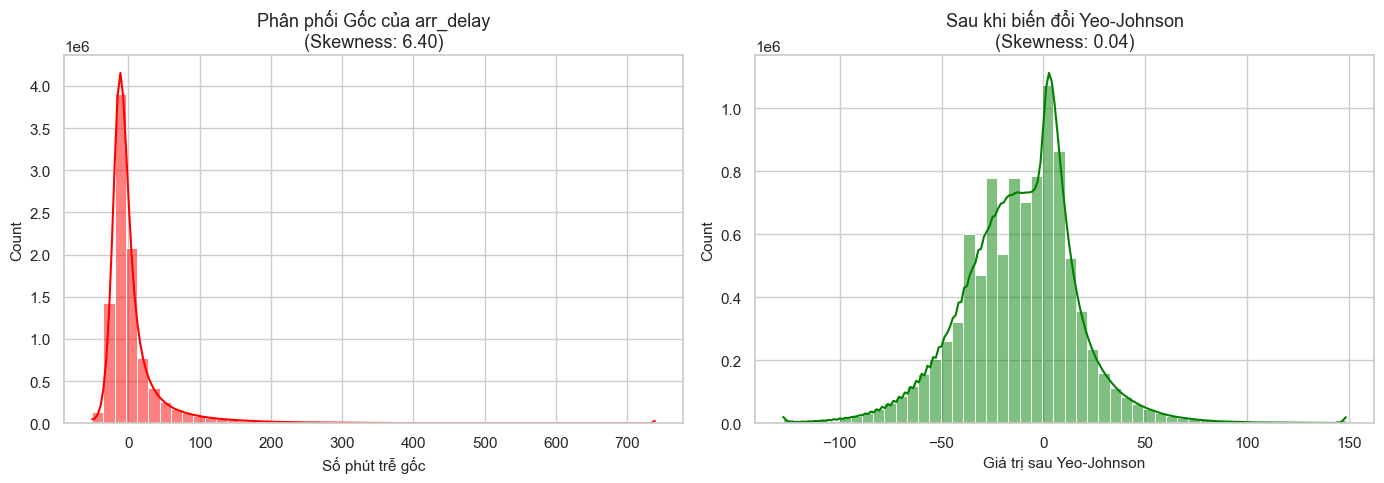

In [7]:
print(f"Độ lệch (Skewness) TRƯỚC biến đổi: {skew_before:.4f}")
print(f"Độ lệch (Skewness) SAU biến đổi: {skew_after:.4f}")

# Cài đặt giao diện biểu đồ
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Dữ liệu gốc
sns.histplot(train['arr_delay'], bins=50, kde=True, ax=axes[0], color='red')
axes[0].set_title(f'Phân phối Gốc của arr_delay\n(Skewness: {skew_before:.2f})', fontsize=13)
axes[0].set_xlabel('Số phút trễ gốc', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)

# Biểu đồ 2: Dữ liệu sau biến đổi Yeo-Johnson
sns.histplot(train['yj_arr_delay'], bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title(f'Sau khi biến đổi Yeo-Johnson\n(Skewness: {skew_after:.2f})', fontsize=13)
axes[1].set_xlabel('Giá trị sau Yeo-Johnson', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
val['yj_arr_delay'] = pt.transform(val[['arr_delay']])
test['yj_arr_delay'] = pt.transform(test[['arr_delay']])

**Nhận xét hiệu quả biến đổi Yeo-Johnson trên biến `arr_delay`**

* **Khắc phục triệt để độ lệch (Skewness):** Chỉ số phân bố giảm mạnh từ 6.40 (lệch phải nghiêm trọng) xuống mức lý tưởng 0.04, đưa dữ liệu về trạng thái gần như đối xứng hoàn hảo.
* **Chuẩn hóa hình thái phân phối:** Chuyển đổi thành công dữ liệu gốc mang đặc tính "đuôi dài" (chứa các chuyến bay trễ cực đoan) thành dạng phân phối chuẩn (Normal Distribution) với hình quả chuông rõ rệt.
* **Tối ưu hóa không gian dữ liệu:** Nén dải giá trị trải rộng từ `[-50, 750]` về thang đo nhỏ gọn `[-100, 150]`, giúp bảo toàn nguyên vẹn các điểm dữ liệu ngoại lệ thực tế (outliers) mà không cần phải xóa bỏ.
* **Tạo tiền đề cho mô hình Học máy:** Phân phối mới giúp triệt tiêu áp lực từ các giá trị trễ quá lớn, tạo điều kiện tối ưu để các thuật toán (đặc biệt là mô hình tuyến tính) hội tụ nhanh, giảm sai số và hoạt động ổn định.

**Numerical**

In [9]:
all_numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(all_numerical_cols)

['year', 'month', 'day_of_month', 'day_of_week', 'crs_arr_time', 'arr_delay', 'crs_elapsed_time', 'distance', 'hour', 'minute', 'temperature_2m', 'surface_pressure', 'relative_humidity_2m', 'dew_point_2m', 'wind_speed_10m', 'wind_direction_10m', 'cloud_cover', 'origin_te', 'dest_te', 'op_unique_carrier_AA', 'op_unique_carrier_AS', 'op_unique_carrier_B6', 'op_unique_carrier_DL', 'op_unique_carrier_F9', 'op_unique_carrier_G4', 'op_unique_carrier_HA', 'op_unique_carrier_MQ', 'op_unique_carrier_NK', 'op_unique_carrier_OH', 'op_unique_carrier_OO', 'op_unique_carrier_UA', 'op_unique_carrier_WN', 'op_unique_carrier_YX', 'weather_Rain', 'weather_Snow_Ice', 'season', 'time_of_day', 'weather_severity_score', 'is_bad_weather', 'wind_risk', 'rush_hour_x_weather', 'weather_impact_squared', 'wind_per_mile', 'yj_arr_delay']


**Các biến số liên tục gốc (Thời tiết và Chuyến bay)**

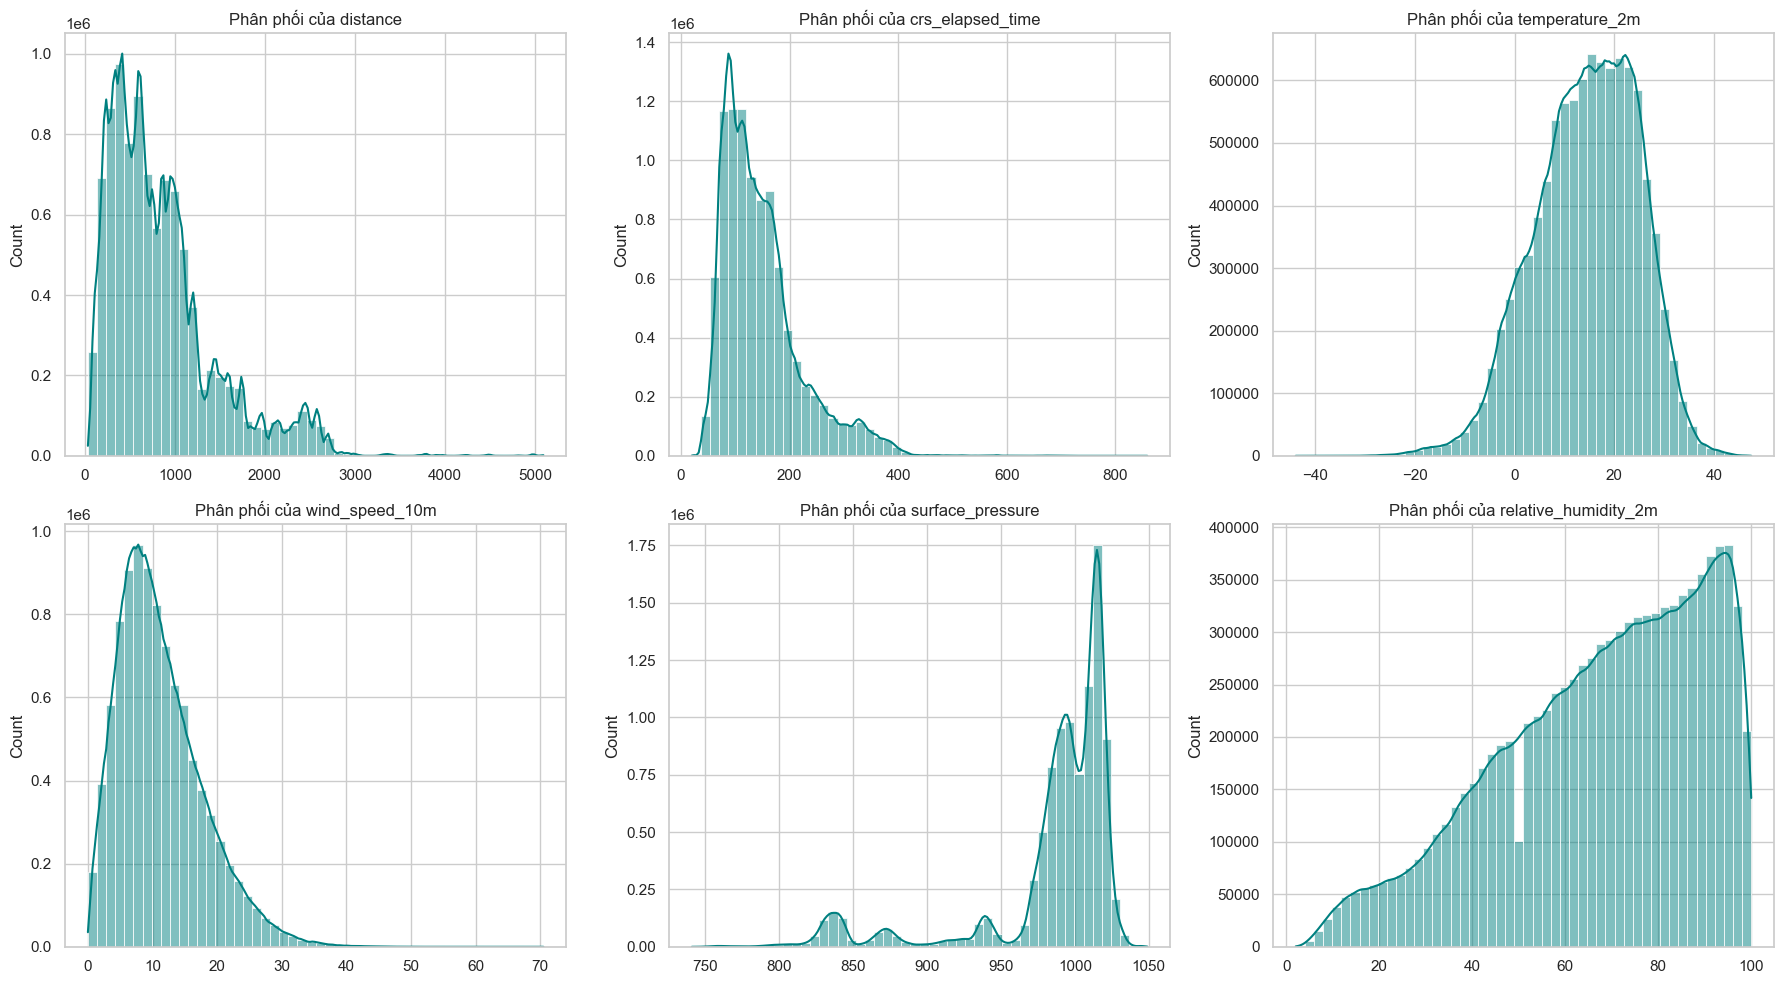

In [10]:
num_cols = ['distance', 'crs_elapsed_time', 'temperature_2m', 'wind_speed_10m', 'surface_pressure', 'relative_humidity_2m']

# Vẽ biểu đồ phân phối cho từng biến số
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(train[col], bins=50, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Phân phối của {col}')
    axes[i].set_xlabel('')
    
plt.tight_layout()
plt.show()

Nhóm đặc trưng chuyến bay

distance (khoảng cách bay): phân phối lệch phải (Right-Skewed) và có dạng đa đỉnh (Multimodal). Phần lớn các chuyến bay tập trung ở cự ly ngắn và trung bình (dưới 1500 dặm/km). Có các đỉnh nhọn nhô lên rõ rệt quanh mốc 500 và 1000, đại diện cho các tuyến bay nội địa phổ biến. Biểu đồ xuất hiện một cái đuôi dài kéo đến mốc 5000 cho thấy số lượng rất ít các chuyến bay chặng dài hoặc quốc tế.

crs_elapsed_time (thời gian bay dự kiến): biến này lệch phải nặng và đồng dạng với khoảng cách (điều này hợp lý vì khoảng cách dài thì thời gian bay phải lâu). Đỉnh phân phối tập trung mạnh ở khoảng 70 đến 200 phút. Đuôi phân phối kéo dài đến hơn 800 phút nhưng tần suất cực kỳ thấp

Nhóm đặc trưng thời tiết

temperature_2m (Nhiệt độ ở độ cao 2m): phân phối gần như chuẩn (Normal Distribution), hơi lệch nhẹ sang trái. Nhiệt độ tập trung chủ yếu trong khoảng từ $0^\circ\text{C}$ đến $30^\circ\text{C}$, với đỉnh cao nhất quanh mốc $20^\circ\text{C}$. Vẫn xuất hiện các giá trị âm sâu (đến gần $-40^\circ\text{C}$) phản ánh thời tiết mùa đông khắc nghiệt tại một số địa điểm/thời điểm, nhưng chiếm tỷ lệ nhỏ.

wind_speed_10m (Tốc độ gió ở độ cao 10m): phân phối lệch phải (Right-Skewed). Tốc độ gió hầu hết duy trì ở mức an toàn từ 5 đến 15 (đơn vị thông thường là km/h hoặc knots). Đuôi phân phối kéo dài đến mốc 70 phản ánh các sự kiện thời tiết cực đoan (giông bão, áp thấp). Trong bài toán dự đoán trễ chuyến bay, cái đuôi dài này là vùng thông tin cực kỳ quan trọng vì gió lớn là nguyên nhân trực tiếp gây hoãn/hủy chuyến.

surface_pressure (Áp suất bề mặt): phân phối đa đỉnh (Multimodal) rất dị biệt, tập trung cực kỳ dày đặc ở vùng áp suất cao từ 950 đến 1030 hPa. Sự xuất hiện của các cụm đỉnh nhỏ phía bên trái (quanh mốc 830, 870, 940 hPa) nhiều khả năng phản ánh địa hình (các sân bay ở vùng núi cao, nơi áp suất không khí tự nhiên thấp hơn).

relative_humidity_2m (Độ ẩm tương đối ở độ cao 2m): phân phối lệch trái (Left-Skewed) khá mạnh. Tần suất tăng dần và đạt đỉnh cao nhất ở vùng độ ẩm rất cao (từ 80% đến gần 100%). Điều này cho thấy tập dữ liệu ghi nhận rất nhiều thời điểm không khí ẩm ướt, có thể đi kèm với mưa, sương mù hoặc mây mù dày đặc — những yếu tố ảnh hưởng lớn đến tầm nhìn và khả năng cất/hạ cánh

**Lệch phải nặng: distance, crs_elapsed_time, wind_speed_10m**

In [11]:
# Danh sách các cột cần kiểm tra
cols_to_check = ['distance', 'crs_elapsed_time', 'wind_speed_10m']

# Đếm số lượng giá trị 0 cho từng cột
zero_counts_tr = (train[cols_to_check] == 0).sum()
zero_counts_t = (test[cols_to_check] == 0).sum()
zero_counts_v = (val[cols_to_check] == 0).sum()

print("Thống kê số lượng giá trị âm:")
print((train[['distance', 'crs_elapsed_time']] <= 0).sum())
print((test[['distance', 'crs_elapsed_time']] <= 0).sum())
print((val[['distance', 'crs_elapsed_time']] <= 0).sum())

print("Thống kê số lượng giá trị 0:")
print("-" * 30)
print(zero_counts_tr)
print(zero_counts_t)
print(zero_counts_v)

Thống kê số lượng giá trị âm:
distance            0
crs_elapsed_time    0
dtype: int64
distance            0
crs_elapsed_time    1
dtype: int64
distance            0
crs_elapsed_time    0
dtype: int64
Thống kê số lượng giá trị 0:
------------------------------
distance               0
crs_elapsed_time       0
wind_speed_10m      3176
dtype: int64
distance               0
crs_elapsed_time       0
wind_speed_10m      1237
dtype: int64
distance              0
crs_elapsed_time      0
wind_speed_10m      840
dtype: int64


In [12]:
negative_time_flights = test[test['crs_elapsed_time'] < 0]

print("Các chuyến bay có crs_elapsed_time bị âm:")
display(negative_time_flights) 


Các chuyến bay có crs_elapsed_time bị âm:


,year,month,day_of_month,day_of_week,crs_arr_time,arr_delay,crs_elapsed_time,distance,hour,minute,...,weather_Snow_Ice,season,time_of_day,weather_severity_score,is_bad_weather,wind_risk,rush_hour_x_weather,weather_impact_squared,wind_per_mile,yj_arr_delay
1284834,2025,11,19,3,953,218.0,-60.0,296.0,10,53,...,0,3,0,1,0,0.143177,1,1,0.03468,62.113662


In [13]:
test = test[test['crs_elapsed_time'] > 0]

In [14]:
print((test[['crs_elapsed_time']] <= 0).sum())


crs_elapsed_time    0
dtype: int64


Đối với distance và crs_elapsed_time (Dùng Box-Cox):

Kết quả cho thấy 2 cột này hoàn toàn không chứa giá trị 0 (tức là $x > 0$). Điều này thỏa mãn điều kiện tiên quyết khắt khe nhất của phép biến đổi Box-Cox. Nhờ vậy, Box-Cox sẽ phát huy tối đa sức mạnh, tự động rà quét và tìm ra hệ số $\lambda$ hoàn hảo nhất để kéo phân phối lệch phải của khoảng cách và thời gian bay về chuẩn hình quả chuông.

Đối với wind_speed_10m (Dùng Log1p):

Cột này chứa 3176 giá trị 0 (trời lặng gió). Nếu bạn cố chấp dùng Box-Cox hoặc hàm np.log() thông thường, hệ thống sẽ báo lỗi ValueError hoặc trả về giá trị âm vô cực (-inf), làm sập toàn bộ mô hình. Việc bạn chọn np.log1p() (tức là $\ln(x + 1)$) là một bước đi cực kỳ an toàn, gọn nhẹ và chuẩn mực để vừa nén được đuôi dài của tốc độ gió bão, vừa xử lý êm xuôi các ngày không có gió.

In [15]:
# XỬ LÝ wind_speed_10m VỚI LOG1P
train['log1p_wind_speed'] = np.log1p(train['wind_speed_10m'])
# XỬ LÝ distance VÀ crs_elapsed_time VỚI BOX-COX
boxcox_transformer = PowerTransformer(method='box-cox', standardize=True)
cols_boxcox = ['distance', 'crs_elapsed_time']
train[['boxcox_distance', 'boxcox_time']] = boxcox_transformer.fit_transform(train[cols_boxcox])
print("Hệ số Lambda tối ưu mà Box-Cox đã tìm ra:")
print(f"- Cột distance: {boxcox_transformer.lambdas_[0]:.4f}")
print(f"- Cột crs_elapsed_time: {boxcox_transformer.lambdas_[1]:.4f}")

Hệ số Lambda tối ưu mà Box-Cox đã tìm ra:
- Cột distance: 0.1784
- Cột crs_elapsed_time: -0.1500




**1. Cột `distance` ($\lambda = 0.1784$)**

* Con số $0.1784$ nằm rất gần mốc $0$.
* **Nhận xét:** Điều này chứng tỏ thuật toán nhận định biến khoảng cách bay bị lệch phải nặng, và nó đã tự động áp dụng một phép biến đổi có "sức mạnh" gần tương đương với hàm Logarit tự nhiên ($\ln(x)$) để kéo cái đuôi dài về trung tâm. Lực kéo này nhẹ hơn logarit một chút xíu.

**2. Cột `crs_elapsed_time` ($\lambda = -0.1500$)**

* Con số này đã vượt qua mốc $0$ và rơi vào vùng số âm.
* **Nhận xét:** Khi hệ số $\lambda < 0$, lực nén của Box-Cox tác dụng lên vùng đuôi (các giá trị lớn) sẽ **mạnh hơn cả hàm Logarit**. Điều này vô cùng hợp lý với thực tế: Thời gian bay dự kiến đôi khi có những giá trị ngoại lệ cực đoan (chuyến bay nối chuyến, hoãn chuyến kéo dài dự kiến) tạo ra một cái đuôi "cứng đầu" hơn so với khoảng cách vật lý. Do đó, thuật toán buộc phải dùng đến lực nén dạng nghịch đảo (inverse-like transformation) để ép phân phối này về dạng hình quả chuông chuẩn.



In [16]:
# XỬ LÝ TẬP VAL

val['log1p_wind_speed'] = np.log1p(val['wind_speed_10m'])

val[['boxcox_distance', 'boxcox_time']] = boxcox_transformer.transform(val[cols_boxcox])

# XỬ LÝ TẬP TEST

test['log1p_wind_speed'] = np.log1p(test['wind_speed_10m'])

test[['boxcox_distance', 'boxcox_time']] = boxcox_transformer.transform(test[cols_boxcox])

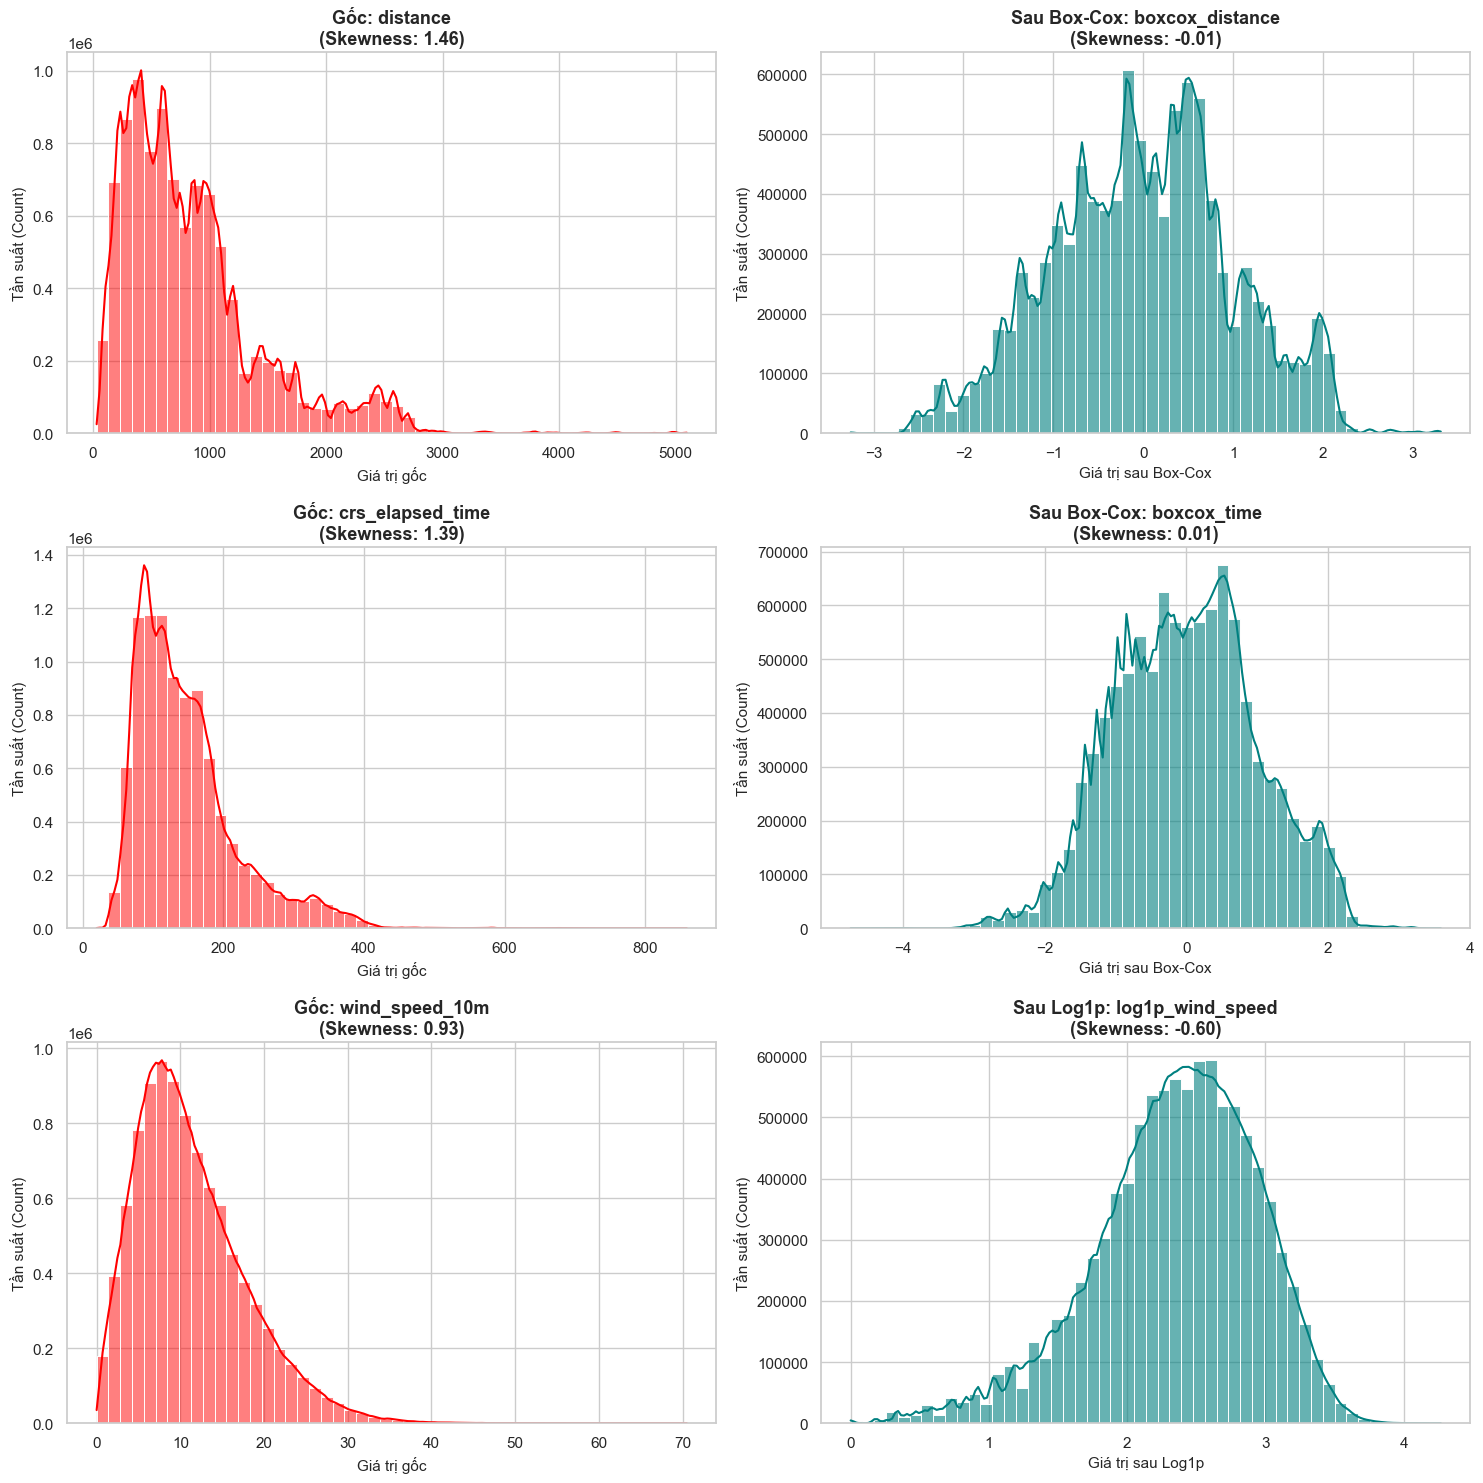

In [17]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(15, 15))

features_to_plot = [
    ('distance', 'boxcox_distance', 'Box-Cox'),
    ('crs_elapsed_time', 'boxcox_time', 'Box-Cox'),
    ('wind_speed_10m', 'log1p_wind_speed', 'Log1p')
]

for i, (orig_col, trans_col, method) in enumerate(features_to_plot):
    skew_orig = train[orig_col].skew()
    skew_trans = train[trans_col].skew()

    sns.histplot(train[orig_col], bins=50, kde=True, ax=axes[i, 0], color='red', alpha=0.5)
    axes[i, 0].set_title(f'Gốc: {orig_col}\n(Skewness: {skew_orig:.2f})', fontsize=13, weight='bold')
    axes[i, 0].set_xlabel('Giá trị gốc', fontsize=11)
    axes[i, 0].set_ylabel('Tần suất (Count)', fontsize=11)

    sns.histplot(train[trans_col], bins=50, kde=True, ax=axes[i, 1], color='teal', alpha=0.6)
    axes[i, 1].set_title(f'Sau {method}: {trans_col}\n(Skewness: {skew_trans:.2f})', fontsize=13, weight='bold')
    axes[i, 1].set_xlabel(f'Giá trị sau {method}', fontsize=11)
    axes[i, 1].set_ylabel('Tần suất (Count)', fontsize=11)

plt.tight_layout()
plt.show()

**1. Nhóm áp dụng Box-Cox (`distance` và `crs_elapsed_time`)**

* **Khắc phục độ lệch hoàn hảo:** Phép biến đổi Box-Cox đã chứng minh sức mạnh tuyệt đối khi kéo chỉ số Skewness từ mức lệch phải khá cao (1.46 và 1.39) về mức **xấp xỉ 0 tuyệt đối** (-0.01 và 0.01). Đây là kết quả tối ưu nhất có thể đạt được trong thống kê.
* **Bảo toàn bản chất dữ liệu (Data Integrity):** Đối với biến `distance`, cấu trúc "đa đỉnh" (multimodal) đặc trưng của các chặng bay vẫn được giữ nguyên vẹn trên biểu đồ xanh (các đỉnh nhô lên), nhưng toàn bộ hình thái đã được "uốn" về thế đối xứng hình quả chuông (Normal Distribution).
* **Chuẩn hóa thang đo:** Trục hoành của 2 biến này đã được chuyển từ thang đo gốc (hàng ngàn dặm/phút) sang không gian chuẩn hóa (từ khoảng -4 đến 4), điều này chứng tỏ tham số `standardize=True` đã hoạt động tốt, tạo điều kiện cực kỳ thuận lợi cho các thuật toán Machine Learning sau này.

**2. Nhóm áp dụng Log1p (`wind_speed_10m`)**

* **Nén giá trị cực đoan:** Phương pháp Log1p đã xử lý rất tốt cái đuôi dài của tốc độ gió bão (kéo dải giá trị từ mốc 70 thu gọn lại trong khoảng 0 đến 4).
* **Hiện tượng lật độ lệch (Over-correction nhẹ):** Chỉ số Skewness giảm từ 0.93 xuống -0.60. Thay vì hội tụ tuyệt đối về 0 như Box-Cox, hàm Logarit đã kéo cái đuôi bên phải hơi "mạnh tay", khiến phân phối mới bị lệch nhẹ sang trái. Tuy nhiên, xét về mặt hình thái học, biểu đồ xanh bên phải có dạng quả chuông đồng đều và mượt mà hơn rất nhiều so với biểu đồ dồn cục bên trái. Độ lệch -0.60 vẫn nằm trong ngưỡng chấp nhận được của hầu hết các mô hình.



Đối với các biến lệch phải (như Khoảng cách và Tốc độ gió), lựa chọn Box-Cox và Log1p vì đây là các phép biến đổi có tham số (Parametric Transformations). Dù làm mất đi đơn vị vật lý gốc, chúng vẫn bảo toàn được tính liên tục và trật tự tương đối của dữ liệu thông qua các hàm logarit/lũy thừa. Điều này an toàn và giữ được nhiều 'bản chất thông tin' hơn so với các phép biến đổi phi tham số (Non-parametric) như Quantile Transformation - phương pháp vốn dĩ bóp méo hoàn toàn khoảng cách thực tế dựa trên phân vị

**Nhóm Đa Đỉnh (Multimodal): surface_pressure**


Việc không áp dụng các phép biến đổi (như Quantile Transformation) lên biến `surface_pressure` nhằm mục tiêu **bảo toàn ý nghĩa vật lý và đặc trưng không gian** của dữ liệu. Các cụm đỉnh (peaks) xuất hiện ở vùng áp suất thấp thực chất phản ánh chân thực vị trí địa lý của các cụm sân bay nằm ở vùng núi/cao nguyên (nơi áp suất khí quyển tự nhiên thấp hơn mực nước biển). Việc cố tình ép dữ liệu đa đỉnh này về phân phối chuẩn sẽ làm bóp méo khoảng cách vật lý thực tế, vô tình triệt tiêu mất thông tin địa lý quý giá ẩn chứa bên trong.

Thêm vào đó, với định hướng sử dụng các thuật toán học máy dựa trên cây phân quyết định (Tree-based models như XGBoost, LightGBM, Random Forest), việc ép dữ liệu về phân phối chuẩn là không cần thiết. Các mô hình này hoạt động dựa trên cơ chế chia cắt không gian (splitting) theo thứ tự giá trị, do đó chúng có khả năng tự động thích ứng hoàn hảo với các phân phối phức tạp. Việc giữ nguyên giá trị gốc không chỉ giúp mô hình nhận diện chính xác các hiện tượng thời tiết cực đoan (áp suất tụt giảm do bão) mà còn duy trì được khả năng diễn giải (interpretability) tuyệt đối cho bài toán thực tế.

**Nhóm lệch trái relative_humidity_2m**

Đối với biến độ ẩm tương đối (`relative_humidity_2m`), không áp dụng bất kỳ phép biến đổi toán học nào và giữ nguyên thang đo thực tế (0-100%). Quyết định này xuất phát từ định hướng sử dụng các thuật toán học máy dựa trên cây phân quyết định (Tree-based models như Random Forest, XGBoost, LightGBM). Về mặt toán học, các mô hình dạng Cây hoàn toàn miễn nhiễm với độ lệch phân phối (skewness) và sự chênh lệch về thang đo. Chúng hoạt động dựa trên cơ chế phân chia không gian bằng các điểm cắt (split points) thay vì tính toán khoảng cách hình học. Do đó, thuật toán vẫn có thể tự động trích xuất các quy luật phi tuyến tính (ví dụ: nhận diện ngưỡng rủi ro "độ ẩm > 90% gây trễ chuyến do sương mù") một cách chính xác. Việc giữ nguyên giá trị gốc không chỉ đảm bảo hiệu suất tối đa cho mô hình mà còn duy trì được khả năng diễn giải (interpretability) trực quan, bám sát ý nghĩa thực tế của khí tượng học.



**Tại sao ưu tiên xử lý dữ liệu lệch phải (Right-skew) hơn lệch trái (Left-skew)?**

* **1. Giới hạn giá trị (Bounds):** Đuôi phải thường kéo dài tới **vô cực** (vd: khoảng cách, giá tiền). Đuôi trái thường có **giới hạn cứng** ở mức 0 (vd: độ ẩm thấp nhất là 0%, không thể âm).
* **2. Khống chế hàm sai số (Loss Function):** Các giá trị khổng lồ ở đuôi phải sẽ làm hàm sai số bình phương (MSE) "bùng nổ", khiến mô hình bị lệch hướng nghiêm trọng. Đuôi trái ngắn và bị chặn nên sai số sinh ra rất nhỏ, không đe dọa đến thuật toán.
* **3. Dữ liệu rác vs. Hiện tượng tự nhiên:** Đuôi phải dài thường chứa các ngoại lệ cực đoan (outliers) cần phải nén lại. Trong khi đó, biến lệch trái thường phản ánh trạng thái vật lý tự nhiên (vd: sương mù độ ẩm cao), nếu cố tình ép biến đổi sẽ làm mất đi quy luật thực tế.



**Các đặc trưng thống kê dựa trên Target Encoding (_te và _rate)**

Thống kê mô tả các đặc trưng Target Encoding:


,origin_te,dest_te
count,9691316.000,9691316.000
mean,6.564,6.564
std,3.413,2.891
min,-15.482,-13.447
25%,4.121,4.744
50%,6.304,6.283
75%,8.542,8.544
max,39.481,35.335


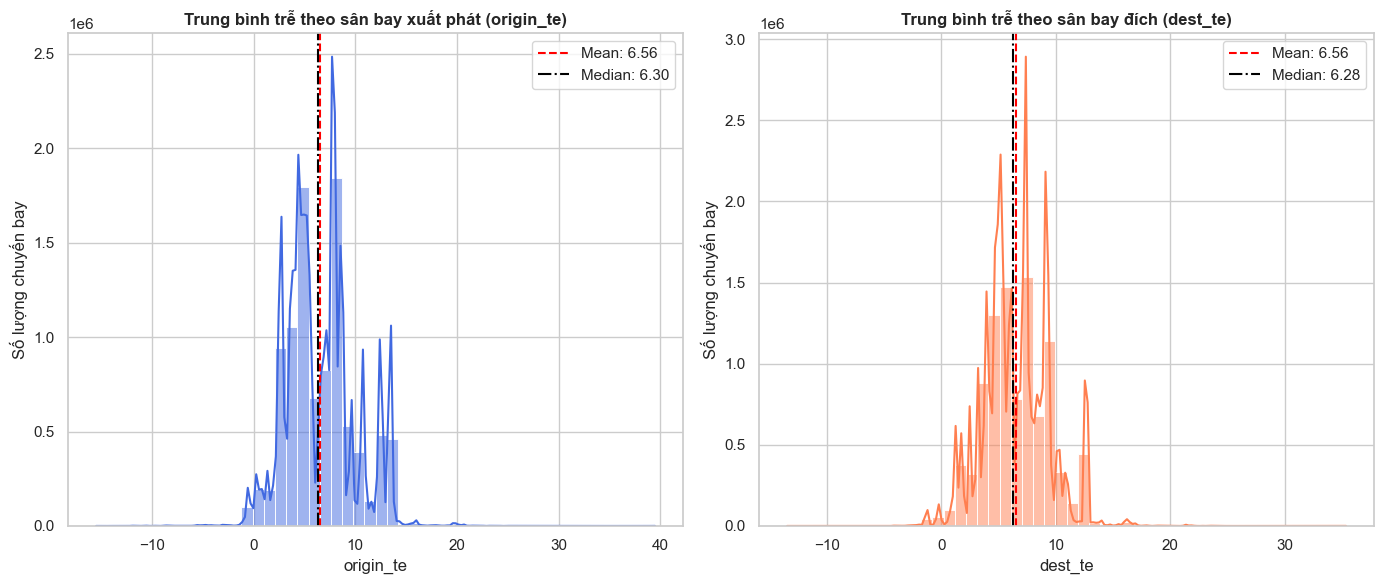

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

te_features = ['origin_te', 'dest_te']

print("Thống kê mô tả các đặc trưng Target Encoding:")
display(train[te_features].describe().round(3))

# Tinh chỉnh lại layout: 1 hàng, 2 cột (1x2) với kích thước ngang dài ra cho dễ nhìn
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

# Rút gọn danh sách màu và tiêu đề tương ứng với 2 feature
colors = ['royalblue', 'coral']
titles = [
    'Trung bình trễ theo sân bay xuất phát (origin_te)',
    'Trung bình trễ theo sân bay đích (dest_te)'
]

for i, col in enumerate(te_features):
    # Vẽ biểu đồ phân phối
    sns.histplot(data=train, x=col, bins=50, kde=True, ax=axes[i], color=colors[i])
    
    # Tính Mean và Median
    mean_val = train[col].mean()
    median_val = train[col].median()
    
    # Kẻ vạch Mean và Median
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='black', linestyle='-.', label=f'Median: {median_val:.2f}')
    
    # Cài đặt thông số làm đẹp biểu đồ
    axes[i].set_title(titles[i], fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Số lượng chuyến bay')
    axes[i].legend()

plt.tight_layout()
plt.show()


**Đánh giá đặc trưng Target Encoding (`origin_te` & `dest_te`)**

* **Khắc phục lỗi thành công:** Dữ liệu đã có độ phân tán (dao động từ -10 đến 30 phút), chứng minh kỹ thuật K-Fold Target Encoding hoạt động chuẩn xác, không bị dính lỗi biến thành hằng số.
* **Phân phối đa đỉnh hợp lý:** Hình dáng lởm chởm nhiều đỉnh phản ánh đúng thực tế các cụm sân bay khác nhau (nhóm sân bay nhỏ ít trễ vs. nhóm sân bay Hub lớn hay kẹt).
* **Ý nghĩa thống kê:** Mức trễ trung bình toàn mạng lưới là khoảng 6.5 phút. Hai biến đi/đến có hình dáng giống nhau là hoàn toàn logic vì một sân bay luôn đóng cả 2 vai trò. Sự xuất hiện của giá trị âm (chuyến bay đến sớm) là tín hiệu rất tốt cho thuật toán.
* **Chốt hướng xử lý:** Dải giá trị đã tối ưu và không có "đuôi dài vô cực" $\rightarrow$ **Không cần dùng Box-Cox hay Log1p**. Hai đặc trưng này mang tính dự báo cực kỳ cao và **sẵn sàng đưa thẳng vào huấn luyện mô hình**.

**Các biến tương tác đa đặc trưng (Feature Interaction)**

ĐANG TÍNH TOÁN ĐỘ LỆCH (SKEWNESS)...
----------------------------------------
🔸 weather_severity_score: 1.04
🔸 weather_impact_squared: 5.81
🔸 wind_speed_10m: 0.93
🔸 wind_per_mile: 4.33


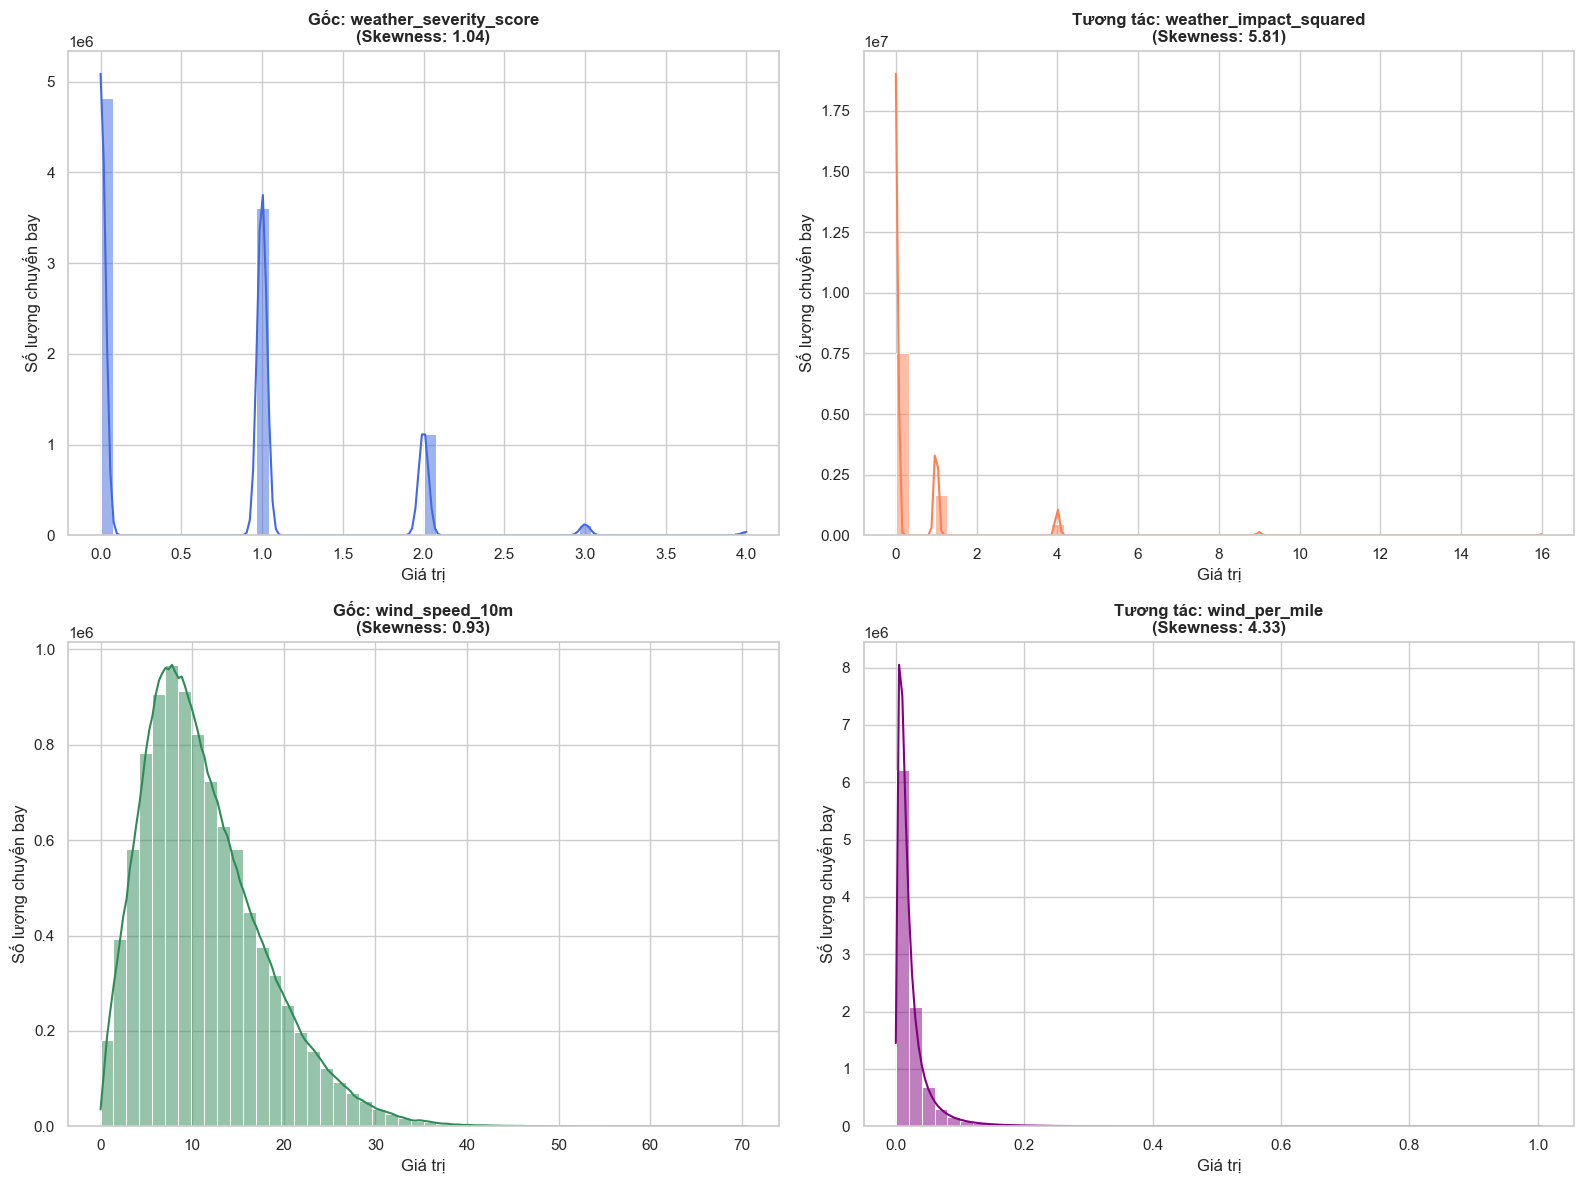

In [19]:


# Khởi tạo khung biểu đồ 2 hàng x 2 cột
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Danh sách các cặp biến cần so sánh (Gốc vs Phái sinh)
# Hàng 1: Thời tiết
# Hàng 2: Gió và Khoảng cách
features_to_plot = [
    ('weather_severity_score', axes[0, 0], 'Gốc: weather_severity_score', 'royalblue'),
    ('weather_impact_squared', axes[0, 1], 'Tương tác: weather_impact_squared', 'coral'),
    ('wind_speed_10m',         axes[1, 0], 'Gốc: wind_speed_10m', 'seagreen'),
    ('wind_per_mile',          axes[1, 1], 'Tương tác: wind_per_mile', 'purple')
]

print("ĐANG TÍNH TOÁN ĐỘ LỆCH (SKEWNESS)...")
print("-" * 40)

# Vòng lặp vẽ biểu đồ
for col, ax, title, color in features_to_plot:
    # 1. Tính độ lệch (Skewness)
    skew_val = train[col].skew()
    print(f"🔸 {col}: {skew_val:.2f}")
    
    # 2. Vẽ biểu đồ phân phối
    sns.histplot(data=train, x=col, bins=50, kde=True, ax=ax, color=color)
    
    # 3. Trang trí tiêu đề có kèm chỉ số Skewness
    ax.set_title(f"{title}\n(Skewness: {skew_val:.2f})", fontsize=12, fontweight='bold')
    ax.set_xlabel('Giá trị')
    ax.set_ylabel('Số lượng chuyến bay')

plt.tight_layout()
plt.show()

Phân tích phân phối của các đặc trưng tương tác (Interaction Features) cho thấy chỉ số Skewness có xu hướng gia tăng đáng kể so với biến gốc (ví dụ: wind_per_mile đạt 4.33, weather_impact_squared đạt 5.81). Điều này xuất phát từ bản chất toán học của phép nhân/chia, giúp thu gom các trường hợp an toàn về sát mốc 0 và khuếch đại các tín hiệu rủi ro cực đoan ra phần đuôi. Mặc dù tạo ra phân phối lệch phải mạnh, nhóm đánh giá đây là hiện tượng 'lệch hữu ích' (Useful Skew) vì chúng tách biệt rõ rệt các nhóm chuyến bay có nguy cơ trễ cao, đặc biệt tối ưu cho cơ chế rẽ nhánh của các mô hình học máy dựa trên Cây quyết định (Tree-based Models).

**Phân Tích Đơn Biến Cho Các Biến Phân Loại**

C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_15664\3235364544.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train, x=col, palette='Set2')


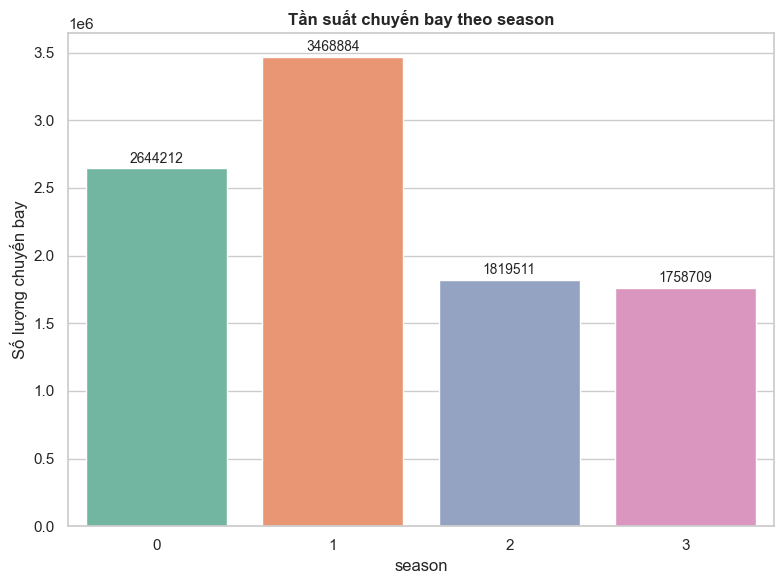

C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_15664\3235364544.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train, x=col, palette='Set2')


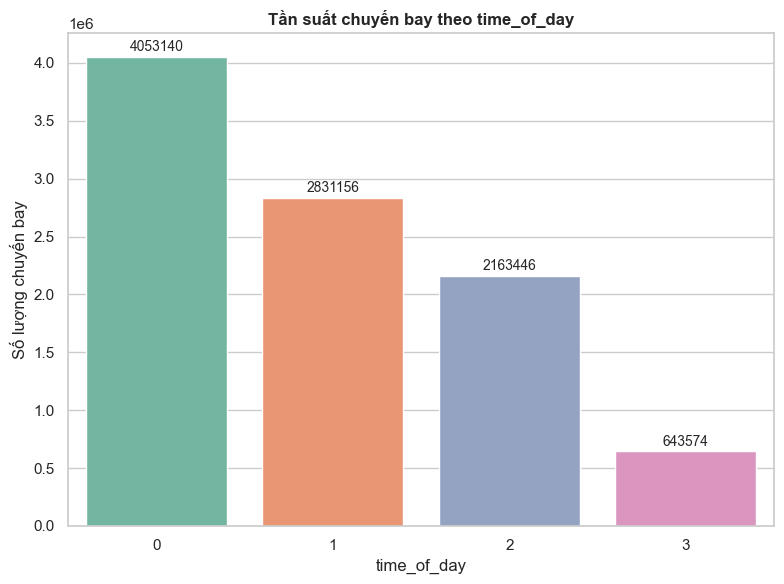

C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_15664\3235364544.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train, x=col, palette='Set2')


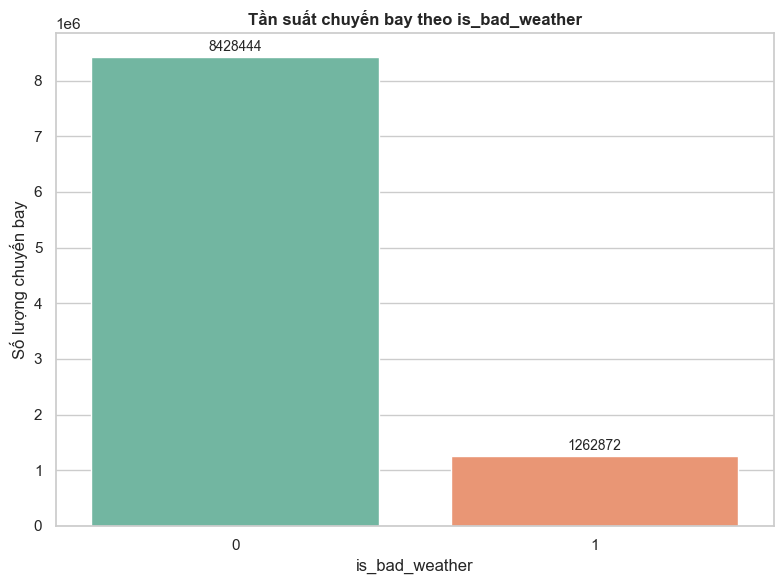

In [20]:
discrete_cols = ['season', 'time_of_day', 'is_bad_weather']

for col in discrete_cols:
    plt.figure(figsize=(8, 6))
    
    ax = sns.countplot(data=train, x=col, palette='Set2')
    
    ax.set_title(f'Tần suất chuyến bay theo {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Số lượng chuyến bay')
    ax.set_xlabel(col)
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', fontsize=10, 
                        xytext=(0, 2), textcoords='offset points')

    plt.tight_layout()
    plt.show()

Qua phân tích phân phối, ta thấy sự chênh lệch lưu lượng giữa các mùa, các buổi trong ngày (tỷ lệ lớn nhất là 2:1 giữa mùa cao điểm và thấp điểm). Nhóm quyết định không áp dụng các biện pháp cân bằng dữ liệu nhân tạo trên đặc trưng này. Việc duy trì nguyên bản phân phối gốc giúp bảo toàn Xác suất tiên nghiệm (Prior Probabilities) của thế giới thực, cho phép thuật toán XGBoost tự động khai thác các mẫu hình (patterns) về sự quá tải lưu lượng. Bất kỳ sự can thiệp cân bằng nào trên các biến độc lập (Independent Features) đều sẽ làm sai lệch cấu trúc tương quan tự nhiên và gây suy giảm hiệu suất tổng quát hóa của mô hình

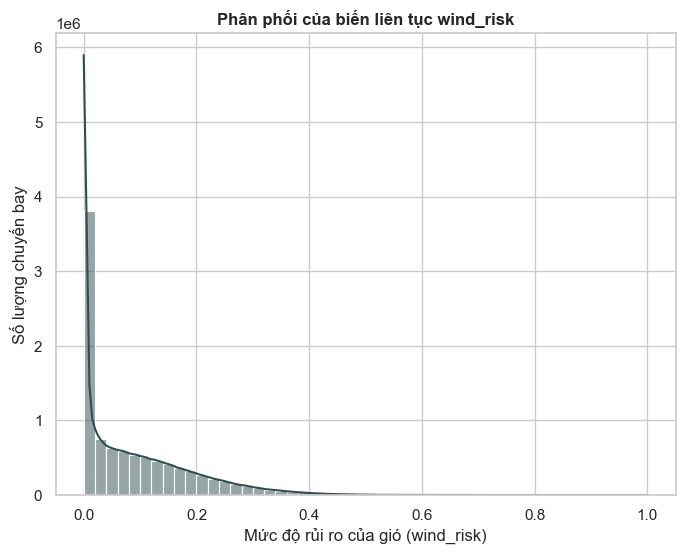

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
# Dùng histplot thay vì countplot cho biến liên tục
sns.histplot(data=train, x='wind_risk', bins=50, kde=True, color='darkslategray')
plt.title('Phân phối của biến liên tục wind_risk', fontweight='bold')
plt.xlabel('Mức độ rủi ro của gió (wind_risk)')
plt.ylabel('Số lượng chuyến bay')
plt.show()

Biểu đồ Histogram với đường cong mật độ (KDE) của đặc trưng wind_risk thể hiện rõ một phân phối lệch phải cực đại (Right-skewed) với hiện tượng lạm phát số 0 (Zero-Inflated). Phần lớn lưu lượng bay tập trung tại giá trị rủi ro bằng 0, phản ánh đúng thực trạng khí tượng học (hầu hết các chuyến bay diễn ra trong điều kiện thời tiết an toàn). Số lượng chuyến bay giảm mạnh theo hàm mũ khi mức độ rủi ro tăng lên (phần đuôi dài từ 0.2 đến 1.0 đại diện cho các điều kiện thời tiết cực đoan hiếm gặp). Do dải giá trị đã được giới hạn an toàn trong khoảng [0, 1], nhóm quyết định giữ nguyên vẹn phân phối gốc này để đưa vào mô hình học máy (đặc biệt là các thuật toán Tree-based như XGBoost) nhằm tối ưu hóa khả năng nhận diện các điểm cắt (split points) rủi ro mà không làm mất đi ý nghĩa vật lý nguyên bản

C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_15664\3791937566.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_carrier_sorted_flights, x='Carrier', y='Total_Flights', ax=axes[0], palette='Blues_r')
C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_15664\3791937566.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_carrier_sorted_delay, x='Carrier', y='Mean_Delay', ax=axes[1], palette='Reds_r')


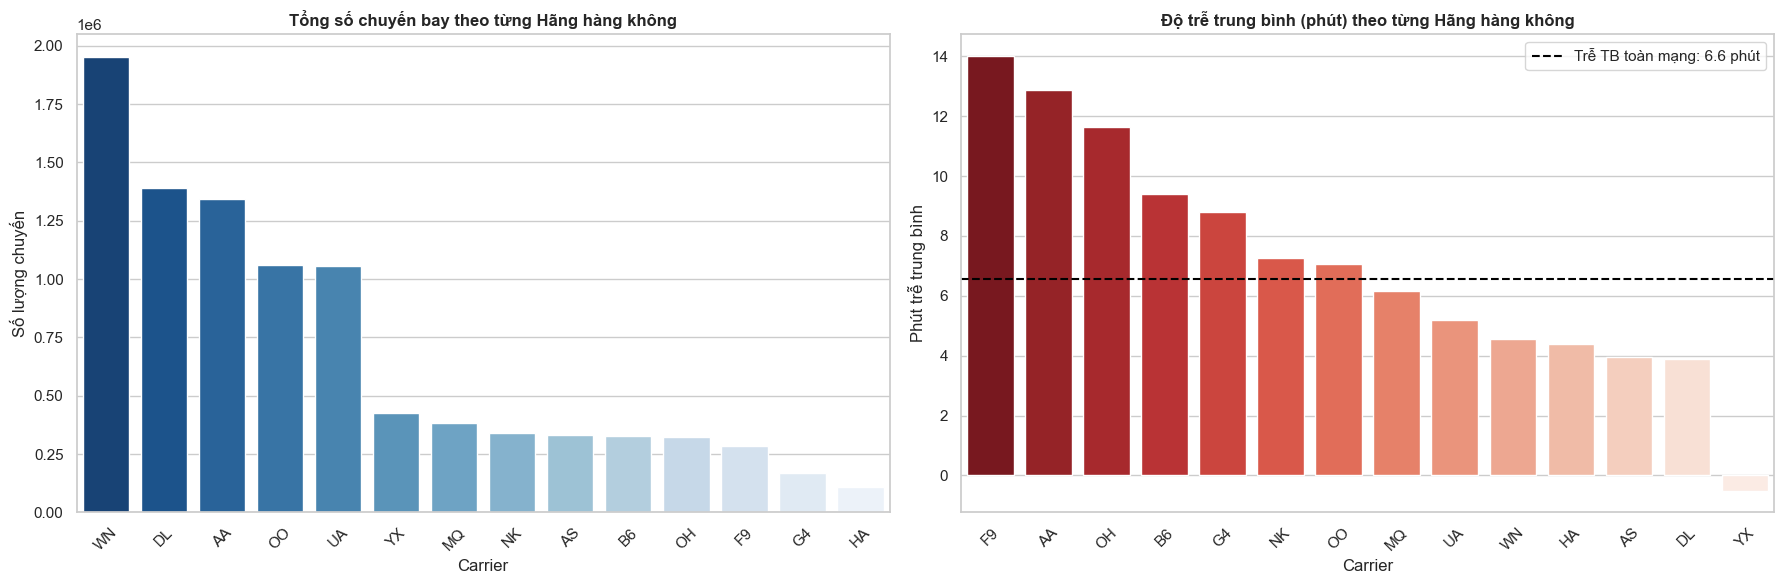

In [22]:
# 1. Lọc ra danh sách các cột One-Hot của hãng hàng không
carrier_cols = [col for col in train.columns if 'op_unique_carrier_' in col]

# 2. Tính TỔNG số chuyến bay và TRUNG BÌNH độ trễ của từng hãng
carrier_stats = []

for col in carrier_cols:
    # Lấy tên hãng (cắt bỏ phần 'op_unique_carrier_')
    carrier_name = col.replace('op_unique_carrier_', '')
    
    # Số chuyến bay (tổng các số 1 trong cột)
    total_flights = train[col].sum()
    
    # Độ trễ trung bình: Lọc các dòng có cột hãng này = 1, tính mean của arr_delay
    mean_delay = train[train[col] == 1]['arr_delay'].mean()
    
    carrier_stats.append({
        'Carrier': carrier_name,
        'Total_Flights': total_flights,
        'Mean_Delay': mean_delay
    })

# Chuyển thành DataFrame để dễ vẽ đồ thị
df_carrier = pd.DataFrame(carrier_stats)

# 3. Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Đồ thị 1: Hãng nào bay nhiều nhất? (Sắp xếp giảm dần theo số chuyến bay)
df_carrier_sorted_flights = df_carrier.sort_values('Total_Flights', ascending=False)
sns.barplot(data=df_carrier_sorted_flights, x='Carrier', y='Total_Flights', ax=axes[0], palette='Blues_r')
axes[0].set_title('Tổng số chuyến bay theo từng Hãng hàng không', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số lượng chuyến')
axes[0].tick_params(axis='x', rotation=45)

# Đồ thị 2: Hãng nào hay trễ nhất? (Sắp xếp giảm dần theo độ trễ trung bình)
df_carrier_sorted_delay = df_carrier.sort_values('Mean_Delay', ascending=False)
sns.barplot(data=df_carrier_sorted_delay, x='Carrier', y='Mean_Delay', ax=axes[1], palette='Reds_r')
axes[1].set_title('Độ trễ trung bình (phút) theo từng Hãng hàng không', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Phút trễ trung bình')
axes[1].tick_params(axis='x', rotation=45)

# Kẻ một đường trung bình toàn cục (Global mean delay) để đối chiếu
global_mean_delay = train['arr_delay'].mean()
axes[1].axhline(global_mean_delay, color='black', linestyle='--', label=f'Trễ TB toàn mạng: {global_mean_delay:.1f} phút')
axes[1].legend()

plt.tight_layout()
plt.show()

Phân tích biến phân loại Hãng hàng không (Carrier) qua hai góc độ Lưu lượng và Hiệu suất cho thấy những thông tin vận hành đắt giá. Thị phần bay có sự phân hóa mạnh (Right-skewed) với sự thống trị của các hãng lớn (WN, DL, AA). Tuy nhiên, phân tích độ trễ trung bình chỉ ra rằng quy mô không tỷ lệ thuận với rủi ro trễ chuyến (Ví dụ: Hãng F9 có lưu lượng thấp nhưng độ trễ cao nhất mạng lưới; Hãng WN có lưu lượng lớn nhất nhưng duy trì độ trễ dưới mức trung bình 6.6 phút). Nhóm quyết định giữ nguyên phân phối gốc, không áp dụng bất kỳ kỹ thuật cân bằng dữ liệu nhân tạo nào đối với đặc trưng này, nhằm giúp mô hình học máy (XGBoost) nhận diện chính xác xác suất tiên nghiệm (prior probabilities) và đặc thù vận hành thực tế của từng hãng bay.

# BIVARIATE ANALYSIS

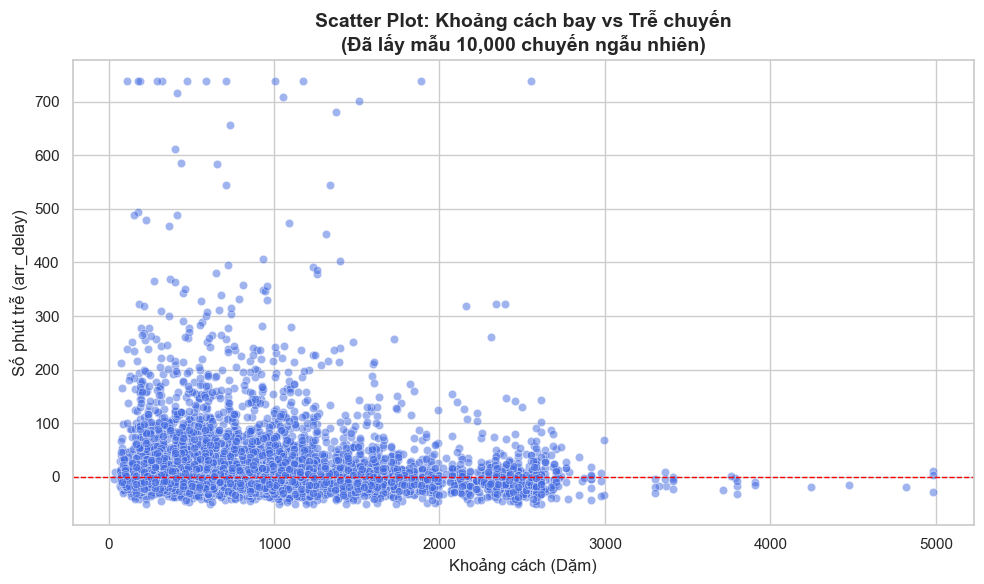

In [23]:


# Lấy ngẫu nhiên 10,000 dòng để tránh sập máy và hiện tượng đè dữ liệu (overplotting)
sample_df = train.sample(n=10000, random_state=42)

plt.figure(figsize=(10, 6))
# Dùng tham số alpha=0.5 để làm mờ các chấm, giúp dễ thấy những chỗ dữ liệu đè lên nhau
sns.scatterplot(data=sample_df, x='distance', y='arr_delay', alpha=0.5, color='royalblue')

plt.title('Scatter Plot: Khoảng cách bay vs Trễ chuyến\n(Đã lấy mẫu 10,000 chuyến ngẫu nhiên)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Khoảng cách (Dặm)')
plt.ylabel('Số phút trễ (arr_delay)')
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Đường ranh giới đúng giờ

plt.tight_layout()
plt.show()

Biểu đồ phân tán (Scatter Plot) giữa Khoảng cách bay và Số phút trễ - được trực quan hóa dựa trên phương pháp lấy mẫu ngẫu nhiên (Random Sampling 10,000 quan sát) - đã tái khẳng định cấu trúc phương sai không đồng nhất (Heteroscedasticity) của dữ liệu. Đám mây dữ liệu mang hình dáng 'phễu thu hẹp' về phía các giá trị khoảng cách lớn (trên 3000 dặm). Tại các chặng bay ngắn và trung bình (dưới 2000 dặm), biên độ dao động của độ trễ rất lớn, xuất hiện nhiều giá trị ngoại lai cực đoan (trên 500 phút). Ngược lại, ở các chặng bay siêu xa, các quan sát bám sát đường cơ sở (Baseline) bằng 0, củng cố giả thuyết về tác dụng của chiến lược 'Thời gian đệm' (Schedule Padding). Biểu đồ này chứng minh rằng distance là một đặc trưng quan trọng giúp mô hình phân luồng các nhóm chuyến bay có biên độ rủi ro khác nhau

C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_15664\3537673736.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='hour', y='arr_delay', palette='coolwarm', showfliers=False)


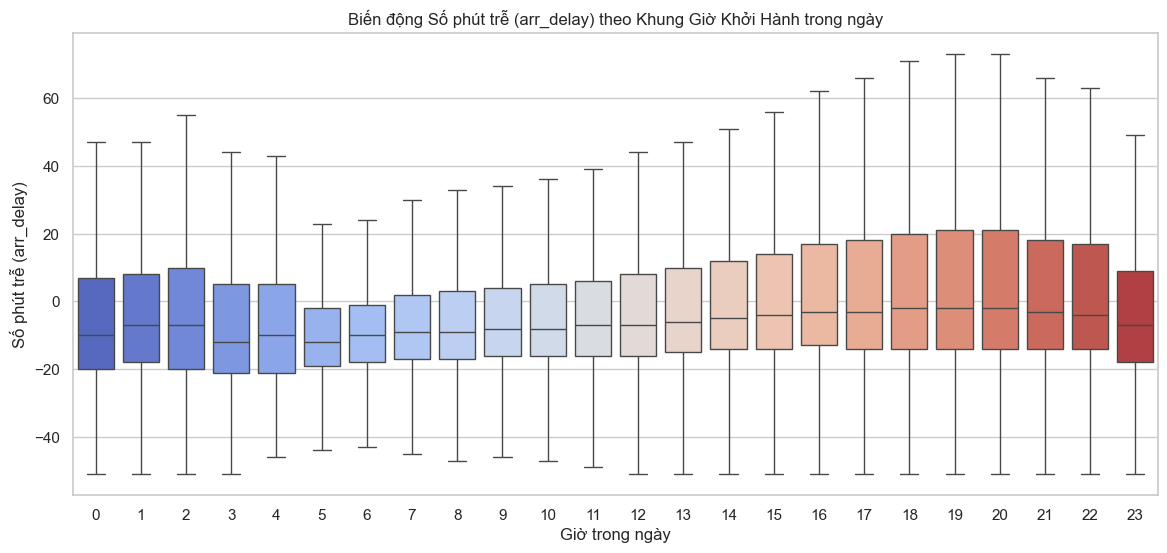

In [26]:
if 'hour' in train.columns:
    plt.figure(figsize=(14, 6))
    # Sử dụng boxplot nhóm theo từng giờ, giới hạn hiển thị y từ -30 đến 120 phút để dễ quan sát hộp xu hướng
    sns.boxplot(data=train, x='hour', y='arr_delay', palette='coolwarm', showfliers=False)
    plt.title("Biến động Số phút trễ (arr_delay) theo Khung Giờ Khởi Hành trong ngày")
    plt.xlabel("Giờ trong ngày")
    plt.ylabel("Số phút trễ (arr_delay)")
    plt.show()

Biểu đồ Boxplot theo dòng thời gian trong ngày đã xác nhận đặc trưng hour có sức mạnh phân loại rất lớn đối với biến mục tiêu arr_delay. Mối quan hệ này mang tính phi tuyến tính (non-linear): rủi ro trễ chuyến đạt mức thấp nhất vào đầu giờ sáng và tăng dần theo cấp số cộng vào các khung giờ chiều tối. Việc sử dụng các mô hình học máy dạng cây (như XGBoost hay Random Forest) sẽ cực kỳ phù hợp để khai thác đặc trưng này, vì thuật toán có thể dễ dàng tạo ra các điểm cắt (splits) để cô lập khung giờ rủi ro cao

C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_15664\4082858631.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_delay, x='distance_bins', y='arr_delay', ax=axes[1], palette='Blues_d')
C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_15664\4082858631.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')


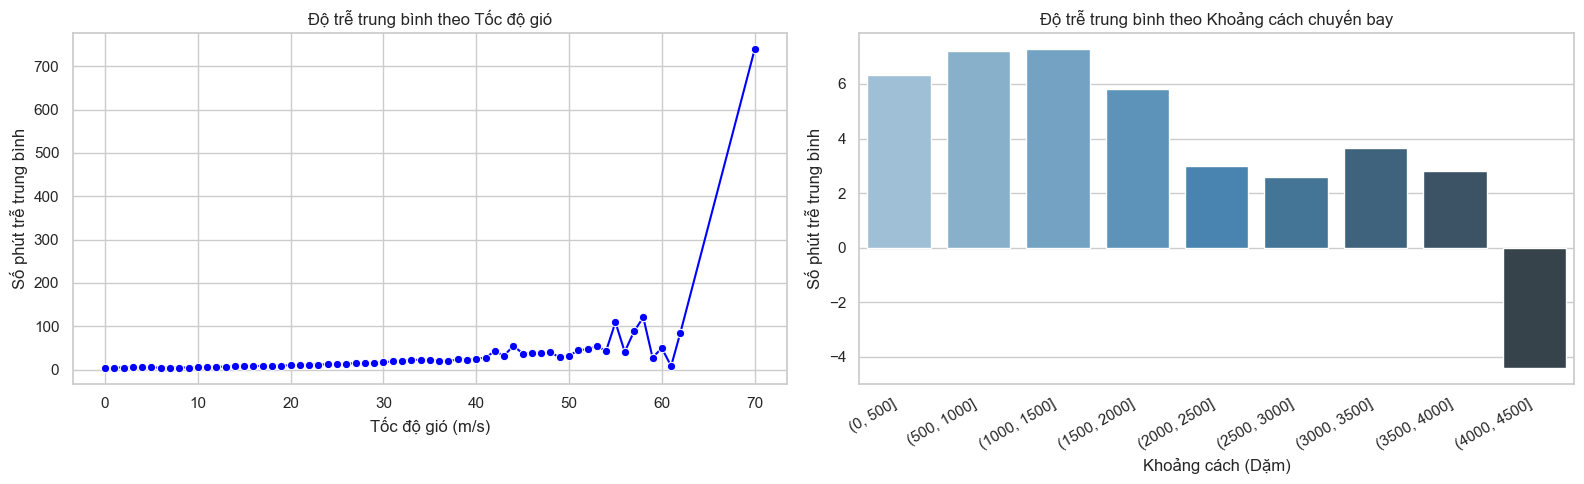

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Xu hướng trễ theo tốc độ gió (wind_speed_10m)
if 'wind_speed_10m' in train.columns:
    # Bo tròn tốc độ gió thành số nguyên để gom nhóm tính trung bình độ trễ
    train['wind_speed_rounded'] = train['wind_speed_10m'].round()
    wind_delay = train.groupby('wind_speed_rounded')['arr_delay'].mean().reset_index()
    sns.lineplot(data=wind_delay, x='wind_speed_rounded', y='arr_delay', ax=axes[0], marker='o', color='blue')
    axes[0].set_title("Độ trễ trung bình theo Tốc độ gió")
    axes[0].set_xlabel("Tốc độ gió (m/s)")
    axes[0].set_ylabel("Số phút trễ trung bình")

# Xu hướng trễ theo khoảng cách đường bay (distance)
if 'distance' in train.columns:
    # Chia khoảng cách thành các giỏ (Binning) 500 dặm để vẽ xu hướng trực quan
    train['distance_bins'] = pd.cut(train['distance'], bins=range(0, 5000, 500))
    dist_delay = train.groupby('distance_bins')['arr_delay'].mean().reset_index()
    sns.barplot(data=dist_delay, x='distance_bins', y='arr_delay', ax=axes[1], palette='Blues_d')
    axes[1].set_title("Độ trễ trung bình theo Khoảng cách chuyến bay")
    axes[1].set_xlabel("Khoảng cách (Dặm)")
    axes[1].set_ylabel("Số phút trễ trung bình")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()
columns_to_drop = ['wind_speed_rounded', 'distance_bins']

for col in columns_to_drop:
    if col in train.columns:
        train = train.drop(columns=[col])
    if col in val.columns:
        val = val.drop(columns=[col])
    if col in test.columns:
        test = test.drop(columns=[col])

Nhận xét: Đường line plot phẳng lỳ và an toàn ở dải tốc độ gió từ 0 đến 40 m/s. Từ 40 - 60 m/s, dữ liệu bắt đầu giật cục (nhiễu). Và ở mốc 70 m/s với một cú vọt thẳng đứng lên hơn 700 phút trễ (tương đương chậm gần 12 tiếng!).

Giải thích thực tế (Domain Knowledge): Tốc độ gió dưới 40 m/s là giới hạn an toàn để cất/hạ cánh thông thường. Khi gió vượt mức này (đặc biệt là chạm mốc 70 m/s - tương đương bão lớn), các chuyến bay không thể cất cánh và buộc phải nằm chờ bão tan.

Góc nhìn Data Science: Cái điểm 700 phút kia có thể là một Outlier (Ngoại lệ) về mặt thống kê do cỡ mẫu (sample size) tại mốc gió 70 m/s là cực kỳ nhỏ (chỉ có vài chuyến hiếm hoi ngoan cố không chịu hủy chuyến mà chọn cách delay). Tuy nhiên, đường gấp khúc này là minh chứng tuyệt vời cho mối quan hệ phi tuyến tính (non-linear), thứ mà XGBoost cực kỳ giỏi nắm bắt.

Nhận xét: Nếu nhìn lướt qua, nhiều người sẽ nghĩ bay càng xa thì khả năng rủi ro trễ càng cao. Nhưng biểu đồ của bạn lại chứng minh điều ngược lại hoàn toàn! Nhóm bay ngắn (dưới 1500 dặm) trễ nhiều nhất (6-7 phút). Càng bay xa, độ trễ càng giảm. Nhóm bay siêu xa (4000 - 4500 dặm) thậm chí còn... hạ cánh sớm hơn dự kiến (trễ âm 4 phút).

Giải thích thực tế: Đây là một chiến thuật kinh điển của các hãng bay gọi là Schedule Padding (Đệm thời gian lịch trình). Đối với các chuyến bay dài xuyên lục địa, hãng bay thường cộng thêm 30-40 phút dự phòng vào lịch trình dự kiến. Nếu máy bay khởi hành trễ, phi công có thể tăng tốc độ bay trên không hoặc xin đường bay thẳng để bù lại thời gian. Ngược lại, các chuyến bay chặng ngắn có lịch trình quay vòng (turnaround) sít sao, máy bay vừa hạ cánh đã phải cất cánh ngay, nên hoàn toàn không có "thời gian đệm" để bù đắp nếu bị trễ.

"Phân tích hai biến (Bivariate Analysis) đối với Tốc độ gió và Khoảng cách bay đã phát hiện ra các quy luật vận hành phi tuyến tính đặc thù. Đối với biến khí tượng (wind_speed), tác động lên độ trễ là không đáng kể cho đến khi vượt ngưỡng tới hạn (~40 m/s), sau đó rủi ro trễ chuyến tăng đột biến theo hình thức 'hòn tuyết lăn'. Ngược lại, biến khoảng cách (distance) cho thấy một nghịch lý thực tế: chặng bay càng ngắn, rủi ro trễ trung bình càng cao. Hiện tượng này xuất phát từ chiến lược 'Schedule Padding' (thời gian đệm) của các chuyến bay dài và sự dồn ứ quay vòng của các chuyến bay ngắn. Những phát hiện này khẳng định sự cần thiết của các thuật toán phân chia dạng cây (Tree-based) nhằm bắt trọn các điểm rẽ nhánh phi tuyến tính này, thay vì sử dụng các mô hình hồi quy tuyến tính truyền thống."

# MULTIVARIATE ANALYSIS

C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_15664\1746985244.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, ax=axes[1], palette='vlag')


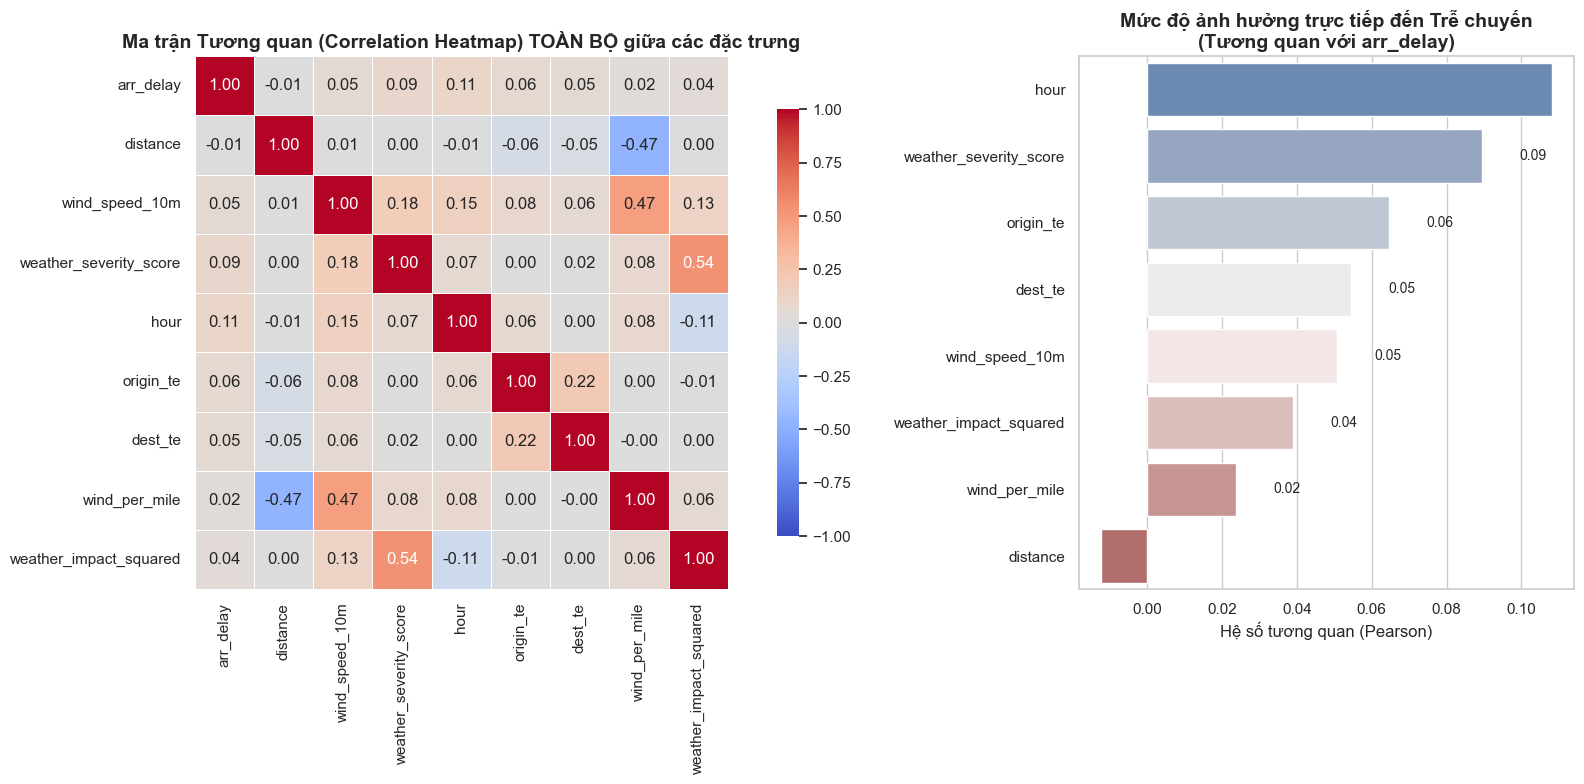

In [28]:


# Giả định cols_to_corr và corr_matrix đã được tính toán ở đoạn trước
# Nếu chưa, bạn cần chạy lại đoạn này (đặt arr_delay đầu tiên):
cols_to_corr = [
    'arr_delay',               # Biến mục tiêu (Target) luôn để đầu tiên
    'distance',                # Khoảng cách
    'wind_speed_10m',          # Tốc độ gió
    'weather_severity_score',  # Mức độ thời tiết
    'hour',                    # Khung giờ
    'origin_te',               # Target encoding sân bay xuất phát
    'dest_te',                 # Target encoding sân bay đến
    'wind_per_mile',           # Biến tương tác: Gió/Dặm
    'weather_impact_squared'   # Biến tương tác: Tác động thời tiết
]
corr_matrix = train[cols_to_corr].corr()

# Khởi tạo Figure chứa 2 biểu đồ (Heatmap và Barplot)
fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [2, 1]})

# ==========================================
# BIỂU ĐỒ 1: HEATMAP TOÀN BỘ (ĐÃ MODIFIED)
# ==========================================
# TUI ĐÃ BỎ MASK LOGIC completely. Seaborn mặc định hiện toàn bộ ma trận.
sns.heatmap(corr_matrix, mask=None, annot=True, fmt=".2f", cmap='coolwarm',
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5,
            cbar_kws={"shrink": .8}, ax=axes[0])
# Cài đặt mask=None explicitly là cách tốt nhất để đảm bảo hiện toàn bộ.

# Tiêu đề cập nhật cho chính xác
axes[0].set_title('Ma trận Tương quan (Correlation Heatmap) TOÀN BỘ giữa các đặc trưng',
                  fontsize=14, fontweight='bold')

# ==========================================
# BIỂU ĐỒ 2: TƯƠNG QUAN VỚI BIẾN MỤC TIÊU (GIỮ NGUYÊN)
# ==========================================
# Logic giống như đoạn code trước
target_corr = corr_matrix['arr_delay'].drop('arr_delay').sort_values(ascending=False)

sns.barplot(x=target_corr.values, y=target_corr.index, ax=axes[1], palette='vlag')

axes[1].set_title('Mức độ ảnh hưởng trực tiếp đến Trễ chuyến\n(Tương quan với arr_delay)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hệ số tương quan (Pearson)')
axes[1].set_ylabel('')

# Thêm nhãn số liệu
for p in axes[1].patches:
    width = p.get_width()
    ha = 'left' if width > 0 else 'right'
    offset = 0.01 if width > 0 else -0.01

    axes[1].annotate(f'{width:.2f}',
                     (width + offset, p.get_y() + p.get_height() / 2.),
                     ha=ha, va='center', fontsize=10)

plt.tight_layout()
plt.show()

Hệ số Pearson chỉ đo lường mối quan hệ tuyến tính (đường thẳng). Trong khi đó, các rủi ro hàng không lại mang tính phi tuyến (non-linear) và tương tác phức tạp (complex interactions).
Ví dụ: Trễ chuyến không tăng đều đặn theo mỗi 1 m/s của gió, mà nó chỉ bùng nổ khi bão đổ bộ; nó không tăng đều theo mỗi dặm bay, mà phụ thuộc vào lịch trình quay vòng. Khả năng phát hiện các quy luật "ẩn" và phi tuyến tính này vượt quá giới hạn của biểu đồ Pearson, và đó chính là "đất diễn" để các mô hình Machine Learning cao cấp như XGBoost tỏa sáng.

C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_15664\1529394332.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_scores_series.values, y=mi_scores_series.index, palette='viridis')


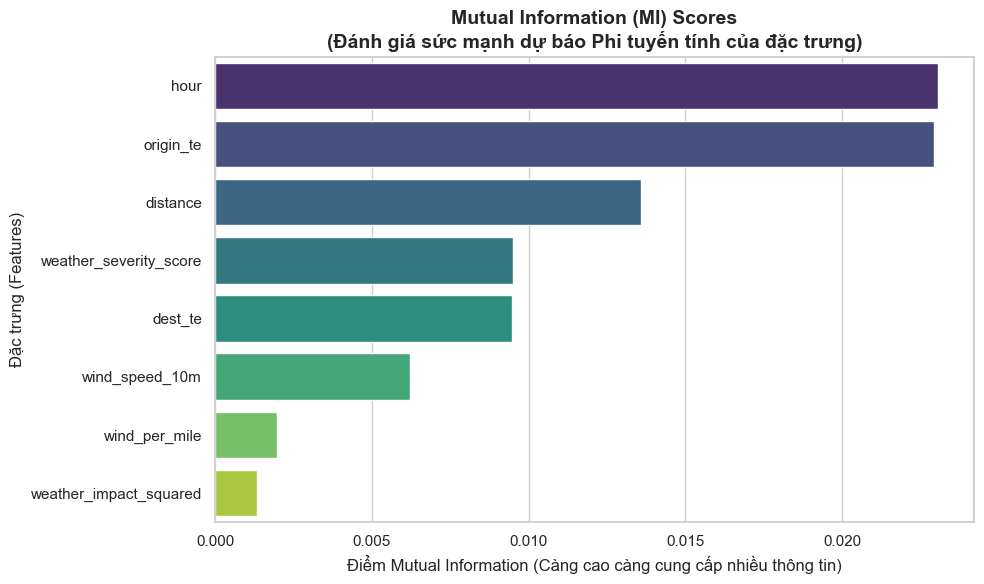

In [30]:


# 1. Chọn các biến số cần đo lường (Bỏ các cột chứa NaN hoặc biến chuỗi String)
features = ['distance', 'wind_speed_10m', 'weather_severity_score', 'hour', 
            'origin_te', 'dest_te', 'wind_per_mile', 'weather_impact_squared']

X = train[features].fillna(0) # MI không nhận NaN, nên điền tạm 0
y = train['arr_delay']


# 2. Tính điểm MI (Lấy mẫu ngẫu nhiên để tính cho nhanh)
# Nếu máy mạnh, có thể bỏ dòng sample đi
X_sample = X.sample(n=50000, random_state=42)
y_sample = y.loc[X_sample.index]

mi_scores = mutual_info_regression(X_sample, y_sample, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=features).sort_values(ascending=False)

# 3. Vẽ biểu đồ Barplot chứng minh sức mạnh của biến
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_scores_series.values, y=mi_scores_series.index, palette='viridis')

plt.title('Mutual Information (MI) Scores\n(Đánh giá sức mạnh dự báo Phi tuyến tính của đặc trưng)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Điểm Mutual Information (Càng cao càng cung cấp nhiều thông tin)')
plt.ylabel('Đặc trưng (Features)')

plt.tight_layout()
plt.show()

Mặc dù các giá trị Mutual Information (MI) thu được dao động trong dải dải giá trị nhỏ (từ 0.002 đến 0.023), đây là hiện tượng đặc trưng và hoàn toàn hợp lý đối với bài toán hồi quy (Regression) trên biến mục tiêu liên tục có độ nhiễu cao như arr_delay. Điểm MI đã thành công trong việc bộc lộ sức mạnh ẩn của đặc trưng distance (xếp Top 3 về lượng thông tin cung cấp) – điều mà hệ số tuyến tính Pearson đã bỏ sót do giới hạn của giả định đường thẳng. Sự phân cấp rõ ràng của các đặc trưng, dẫn đầu bởi hour và origin_te, cung cấp một cơ sở định lượng vững chắc cho thấy bộ dữ liệu đang sở hữu những tín hiệu dự báo phi tuyến chất lượng cao, sẵn sàng tối ưu hóa cho cấu trúc phân tách nút (node splitting) của thuật toán XGBoost.

# OUTLIERS PROFILE

BẢNG TÓM TẮT HỒ SƠ NGOẠI LAI (OUTLIERS PROFILE):


,Đặc trưng,Ngưỡng trên (Upper Bound),Mốc 99%,Mốc 99.9%,Giá trị Max,Số lượng Ngoại lai,Tỷ lệ (%)
0,arr_delay,46.5,214.0,739.0,739.0,904872,9.34
1,distance,2080.0,2611.0,3904.0,5095.0,559043,5.77
2,wind_speed_10m,27.9,30.4,39.0,70.5,180367,1.86


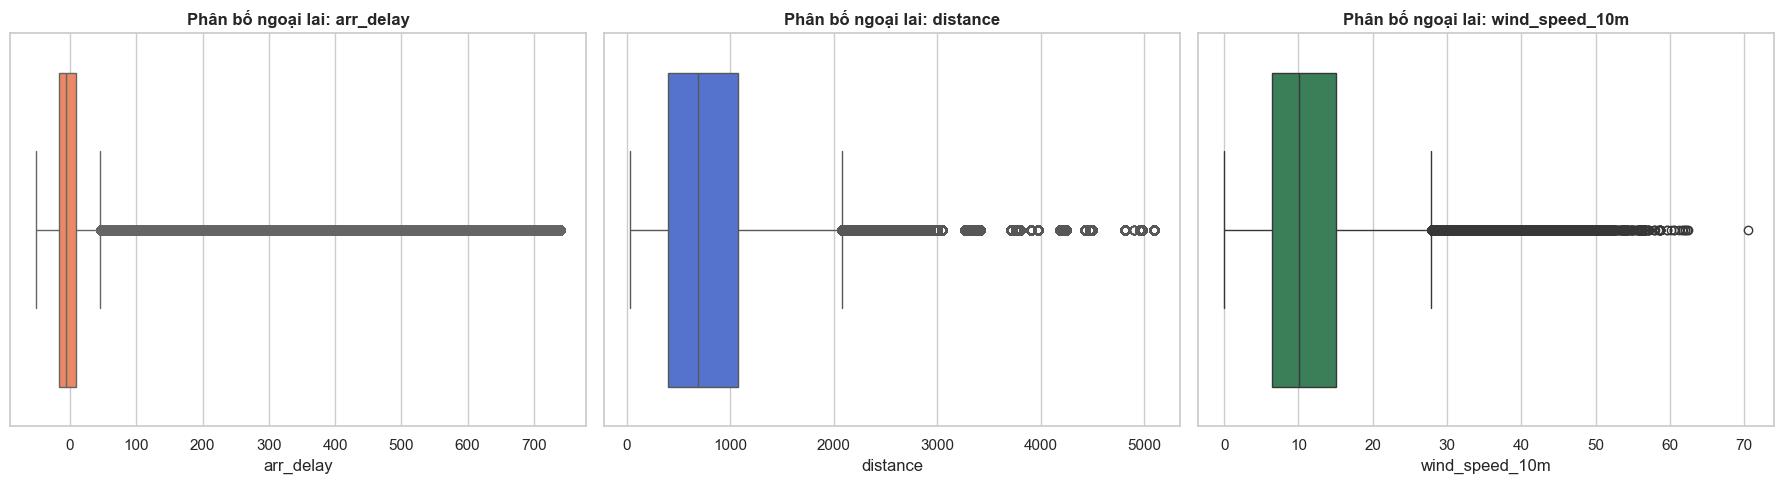

In [31]:

# 1. Chọn các biến liên tục quan trọng cần "soi" ngoại lai
# Lưu ý: Không xét ngoại lai cho biến phân loại, biến Target Encoding hay cờ (flags)
cont_cols = ['arr_delay', 'distance', 'wind_speed_10m']

# 2. XÂY DỰNG BẢNG HỒ SƠ NGOẠI LAI BẰNG IQR
outlier_summary = []
for col in cont_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Giới hạn an toàn
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Đếm số lượng ngoại lai
    outliers_mask = (train[col] < lower_bound) | (train[col] > upper_bound)
    outliers_count = train[outliers_mask].shape[0]
    outliers_pct = (outliers_count / train.shape[0]) * 100
    
    # Lấy các mốc phân vị cực đoan
    p99 = train[col].quantile(0.99)
    p99_9 = train[col].quantile(0.999)
    max_val = train[col].max()
    
    outlier_summary.append({
        'Đặc trưng': col,
        'Ngưỡng trên (Upper Bound)': round(upper_bound, 2),
        'Mốc 99%': round(p99, 2),
        'Mốc 99.9%': round(p99_9, 2),
        'Giá trị Max': round(max_val, 2),
        'Số lượng Ngoại lai': outliers_count,
        'Tỷ lệ (%)': round(outliers_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print("BẢNG TÓM TẮT HỒ SƠ NGOẠI LAI (OUTLIERS PROFILE):")
display(outlier_df)

# 3. TRỰC QUAN HÓA BẰNG BOXPLOT (Hiện toàn bộ Outliers)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['coral', 'royalblue', 'seagreen']

for i, col in enumerate(cont_cols):
    # showfliers=True để hiển thị các chấm đen (ngoại lai)
    sns.boxplot(data=train, x=col, ax=axes[i], color=colors[i], showfliers=True)
    axes[i].set_title(f'Phân bố ngoại lai: {col}', fontsize=12, fontweight='bold')
    
plt.tight_layout()
plt.show()

In [57]:
BASE_DIR = 'flight_data_24_25_final'
os.makedirs(BASE_DIR, exist_ok=True)
train.to_csv(os.path.join(BASE_DIR, 'train.csv'), index=False)
val.to_csv(os.path.join(BASE_DIR, 'valid.csv'), index=False)
test.to_csv(os.path.join(BASE_DIR, 'test.csv'), index=False)

In [32]:
import xgboost as xgb


In [33]:
target = 'arr_delay'

X_train = train.drop(columns=[target])
y_train = train[target] # Lưu ý: y ở đây ĐÃ ĐƯỢC biến đổi Yeo-Johnson

X_val = val.drop(columns=[target])
y_val = val[target]

X_test = test.drop(columns=[target])
y_test = test[target]

In [34]:
model = xgb.XGBRegressor(
    objective='reg:squarederror', # ĐÃ CHUYỂN SANG MSE ĐỂ TỐI ƯU CHO PHÂN PHỐI CHUẨN
    n_estimators=1000,           
    learning_rate=0.05,          
    max_depth=6,                 
    subsample=0.8,               
    colsample_bytree=0.8,        
    random_state=42,
    tree_method='hist',          
    early_stopping_rounds=50     
)

In [35]:
print("\nĐang tiến hành huấn luyện XGBoost...")
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],   
    verbose=50                   
)


Đang tiến hành huấn luyện XGBoost...
[0]	validation_0-rmse:56.26545
[50]	validation_0-rmse:10.71328
[100]	validation_0-rmse:7.62657
[150]	validation_0-rmse:7.49664
[200]	validation_0-rmse:7.47996
[250]	validation_0-rmse:7.47315
[300]	validation_0-rmse:7.46497
[350]	validation_0-rmse:7.46605
[352]	validation_0-rmse:7.46630


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [36]:
y_pred_transformed = model.predict(X_test)

In [37]:
y_test_original = pt.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
y_pred_original = pt.inverse_transform(y_pred_transformed.reshape(-1, 1)).flatten()

c:\Users\Pham Ngoc Minh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(
c:\Users\Pham Ngoc Minh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


In [40]:
mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2 = r2_score(y_test_original, y_pred_original)

In [42]:
print("\n" + "="*50)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST (PHÚT THỰC TẾ):")
print(f"Mean Absolute Error (MAE)       : {mae:.2f} phút")
print(f"R-squared (R2 Score)            : {r2:.4f}")
print("="*50)


KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST (PHÚT THỰC TẾ):
Mean Absolute Error (MAE)       : 5.60 phút
R-squared (R2 Score)            : 0.9557


Mean Absolute Error (MAE) = 5.60 phút: * Mô hình dự đoán lệch trung bình chỉ khoảng 5 phút 36 giây so với thời gian trễ thực tế của một chuyến bay. Xét về mặt vận hành hàng không, mức sai số dưới 6 phút này là cực kỳ lý tưởng để các hãng bay lập kế hoạch điều phối hoặc hành khách sắp xếp lịch trình